# Diferential Expression (DE)

In [1]:
# load packages and user-defined functions
options(warn=-1)
suppressPackageStartupMessages( library( DESeq2 ) )
suppressPackageStartupMessages( library( BiocParallel ) )
library(tidyverse)
library(data.table)
library("AnnotationDbi")
library("org.Hs.eg.db")
library(pathview)
library(gage)
library(gageData)
data(kegg.sets.hs)
data(sigmet.idx.hs)
library(scran)
library('glmGamPoi')
#library(parallel)
library(clusterProfiler)
library(EnhancedVolcano)
library("enrichplot")

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.2     ✔ readr     2.1.4
✔ forcats   1.0.0     ✔ stringr   1.5.0
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.2     ✔ tidyr     1.3.0
✔ purrr     1.0.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ lubridate::%within%() masks IRanges::%within%()
✖ dplyr::collapse()     masks IRanges::collapse()
✖ dplyr::combine()      masks Biobase::combine(), BiocGenerics::combine()
✖ dplyr::count()        masks matrixStats::count()
✖ dplyr::desc()         masks IRanges::desc()
✖ tidyr::expand()       masks S4Vectors::expand()
✖ dplyr::filter()       masks stats::filter()
✖ dplyr::first()        masks S4Vectors::first()
✖ dplyr::lag()          masks stats::lag()
✖ ggplot2::Position()   masks BiocGenerics::Position(), base::Position()
✖ purrr::reduce()       masks GenomicRanges::reduce(), IRanges::reduce()
✖ dplyr::rename()       masks S4Vectors::rename()


In [2]:
suppressMessages(source("code/functions.R"))

In [3]:
reference_cells <- read.csv("output/reference_cell_strict.csv") %>% dplyr::select(experiment,cell)

In [4]:
reference_cells_k6_8 <- read.csv("output/reference_cells_k6-8.csv") %>% dplyr::select(experiment,cell)

In [4]:
head(reference_cells_k6_8)

,experiment,cell
,<chr>,<chr>
1,K7,AAACCTGAGAAACCGC
2,K7,AAACCTGAGACGACGT
3,K7,AAACCTGAGACTTTCG
4,K7,AAACCTGAGAGCTTCT
5,K7,AAACCTGCAGGAATCG
6,K7,AAACCTGGTCCTAGCG


In [5]:
# # seurat object (we are going to use the. non normalize counts)
 FL.integrated <- readRDS("output/FL_CLL_integrated_clean.rds")

In [6]:
#barcodes of cells group 2
cells1 <- read.csv("output/df_summary_complete.csv") %>% mutate(experiment=str_extract(subject, "^.{2}")) %>%
         mutate(cell_seurat=case_when(experiment == "K1" ~ paste0(cell,"-1_1"),
                                                           experiment == "K2" ~ paste0(cell,"-1_2"),
                                                           experiment == "K3" ~ paste0(cell,"-1_3"),
                                                           experiment == "K4" ~ paste0(cell,"-1_4"),
                                                                                             experiment == "K5" ~ paste0(cell,"-1_5"),
                                                                                             experiment == "K6" ~ paste0(cell,"-1_6"),
                                                                                             experiment == "K7" ~ paste0(cell,"-1_7"),
                                                                                             experiment == "K8" ~ paste0(cell,"-1_8"),
                                                                                             TRUE ~ "NA"
                                                                                                 )) %>%
        rename("batch" = "experiment") %>% select(cell_seurat,batch) %>% unique()

In [7]:
cells1 <- cells1 %>% filter(batch %in% c("K6", "K7","K8"))
str(cells1)

'data.frame':	305 obs. of  2 variables:
 $ cell_seurat: chr  "CTGAAGTAGTTTAGGA-1_6" "ACTGAGTTCTACTTAC-1_6" "GACCAATTCAGCATGT-1_6" "ACGATACAGGAGCGAG-1_6" ...
 $ batch      : chr  "K6" "K6" "K6" "K6" ...


In [8]:

#barcodes of cells group 1
# cells2 <- df_seq %>% filter(cell %in% trully_negative$cell) %>% mutate(experiment=str_extract(subject, "^.{2}")) %>% mutate(cell_seurat=case_when(experiment == "K4" ~ paste0(cell,"-1_1"),
#                                                                                              experiment == "K5" ~ paste0(cell,"-1_2"),
#                                                                                              experiment == "K6" ~ paste0(cell,"-1_3"),
#                                                                                              experiment == "K7" ~ paste0(cell,"-1_4"),
#                                                                                              experiment == "K8" ~ paste0(cell,"-1_5"),
#                                                                                              TRUE ~ "NA"
#                                                                                                  )) %>% filter(!cell_seurat %in% cells1) %>%
#            pull(cell_seurat) %>% unique() %>% sample(2000)

cells2 <- reference_cells_k6_8 %>% mutate(cell_seurat=case_when(experiment == "K6" ~ paste0(cell,"-1_6"),
                                                                                             experiment == "K7" ~ paste0(cell,"-1_7"),
                                                                                             experiment == "K8" ~ paste0(cell,"-1_8"),
                                                                                             TRUE ~ "NA"
                                                                                                 )) %>% 
           filter(!cell_seurat %in% cells1$cell_seurat) %>%
           rename("batch" = "experiment") %>% select(cell_seurat,batch) %>% unique()

### K6

In [ ]:
cells2 <- reference_cells_k6_8 %>% filter(experiment == "K6") %>%
             mutate(cell_seurat=case_when(experiment == "K6" ~ paste0(cell,"-1_6"),
                                                                                             experiment == "K7" ~ paste0(cell,"-1_7"),
                                                                                             experiment == "K8" ~ paste0(cell,"-1_8"),
                                                                                             TRUE ~ "NA"
                                                                                                 )) %>% 
           filter(!cell_seurat %in% cells1$cell_seurat) %>%
           rename("batch" = "experiment") %>% select(cell_seurat,batch) %>% unique()

DEgenes <-
  # function that performs DE gene analysis
  # s     = seurat object, corrected for zeroes
  # cell1 = barcodes of cells group 1
  # cell2 = barcodes of cells group 2
  # max   = max cells per group  
  function( sObject, cells1, cells2 ){
    # subset d for cell1 and cell2, for max cells
    d <-
      bind_rows(
        cells1 %>% 
          as.data.frame() %>% 
          mutate( condition = 2 ),
        cells2 %>% 
          as.data.frame() %>% 
          mutate( condition = 1 ) ) %>%
      column_to_rownames( var = "cell_seurat" ) %>% 
      mutate( condition = factor( condition, levels = c( 1, 2 ) ) )
    
    
    # extract count table and subset for cells in colData
    cts <-
      FL.integrated@assays$RNA@counts  %>%
      as.matrix()%>% #add step
      as.data.frame() %>%
      dplyr::select( rownames( d ) ) %>%
     rownames_to_column( var = "geneName" )
    
    # remove RPL, RPS and MT- genes
    cts <-
      cts %>% 
      # filter( !geneName %like% "^RPL",
      #         !geneName %like% "^RPS",
      #        dds <- DEgenes(FL.integrated, cells1, cells2)
      # !geneName %like% "^IG[HKL][LVMCG]",
      #          !geneName %like% "^MT-" ) %>% 
      column_to_rownames( var = "geneName" )
    
    # are colnames in cts similarly ordered as in colData?
    if( all( rownames( d ) == colnames( cts ) ) == FALSE ){
      cts <- cts[ , rownames( d ) ]
      all( rownames( d ) == colnames( cts ) ) }
    
    # create the DESeq2 object
    dds <-
      DESeqDataSetFromMatrix( countData = cts,
                              colData   = d,
                              design    = ~ batch + condition) # ~ batch + condition
    
    # set test and reference
    dds$cluster <-
      relevel( dds$condition, ref = "1" )
      
    
    # add genenames to the DESeq2 object
    mcols( dds ) <-
      DataFrame( mcols( dds ),
                 data.frame( gene = rownames( cts ) ) )
    
    # limit data to genes with total read count >= 1% of cell count in the data
    dds <-
      dds[ rowSums( counts( dds ) ) >= 0.01 * nrow( dds ) , ]
      
    #Estimate size factors
    dds <- estimateSizeFactors(dds, type="poscounts")
    scr <- computeSumFactors(dds)
    
    # use scran's sum factors:
    sizeFactors(dds) <- sizeFactors(scr)
    
    # run
    dds <-
      DESeq( dds,
             fitType = "glmGamPoi", #glmGamPoi
             parallel = FALSE, 
             test="LRT",
             reduced = ~ 1,
             useT=TRUE,
             minmu=1e-6,
             minReplicatesForReplace=Inf,
             BPPARAM = MulticoreParam( detectCores() ) )

    
    return( dds)
  }

dds_k6 <- DEgenes(FL.integrated, cells1, cells2)

### K7

In [ ]:
cells2 <- reference_cells_k6_8 %>% filter(experiment == "K7") %>%
             mutate(cell_seurat=case_when(experiment == "K6" ~ paste0(cell,"-1_6"),
                                                                                             experiment == "K7" ~ paste0(cell,"-1_7"),
                                                                                             experiment == "K8" ~ paste0(cell,"-1_8"),
                                                                                             TRUE ~ "NA"
                                                                                                 )) %>% 
           filter(!cell_seurat %in% cells1$cell_seurat) %>%
           rename("batch" = "experiment") %>% select(cell_seurat,batch) %>% unique()

DEgenes <-
  # function that performs DE gene analysis
  # s     = seurat object, corrected for zeroes
  # cell1 = barcodes of cells group 1
  # cell2 = barcodes of cells group 2
  # max   = max cells per group  
  function( sObject, cells1, cells2 ){
    # subset d for cell1 and cell2, for max cells
    d <-
      bind_rows(
        cells1 %>% 
          as.data.frame() %>% 
          mutate( condition = 2 ),
        cells2 %>% 
          as.data.frame() %>% 
          mutate( condition = 1 ) ) %>%
      column_to_rownames( var = "cell_seurat" ) %>% 
      mutate( condition = factor( condition, levels = c( 1, 2 ) ) )
    
    
    # extract count table and subset for cells in colData
    cts <-
      FL.integrated@assays$RNA@counts  %>%
      as.matrix()%>% #add step
      as.data.frame() %>%
      dplyr::select( rownames( d ) ) %>%
     rownames_to_column( var = "geneName" )
    
    # remove RPL, RPS and MT- genes
     cts <-
       cts %>% 
       # filter( !geneName %like% "^RPL",
       #         !geneName %like% "^RPS",
       #         !geneName %like% "^IG[HKL][LVMCG]",
       #         !geneName %like% "^MT-" ) %>% 
       column_to_rownames( var = "geneName" )
    
    # are colnames in cts similarly ordered as in colData?
    if( all( rownames( d ) == colnames( cts ) ) == FALSE ){
      cts <- cts[ , rownames( d ) ]
      all( rownames( d ) == colnames( cts ) ) }
    
    # create the DESeq2 object
    dds <-
      DESeqDataSetFromMatrix( countData = cts,
                              colData   = d,
                              design    = ~ batch + condition) # ~ batch + condition
    
    # set test and reference
    dds$cluster <-
      relevel( dds$condition, ref = "1" )
      
    
    # add genenames to the DESeq2 object
    mcols( dds ) <-
      DataFrame( mcols( dds ),
                 data.frame( gene = rownames( cts ) ) )
    
    # limit data to genes with total read count >= 1% of cell count in the data
    dds <-
      dds[ rowSums( counts( dds ) ) >= 0.01 * nrow( dds ) , ]
      
    #Estimate size factors
    dds <- estimateSizeFactors(dds, type="poscounts")
    scr <- computeSumFactors(dds)
    
    # use scran's sum factors:
    sizeFactors(dds) <- sizeFactors(scr)
    
    # run
    dds <-
      DESeq( dds,
             fitType = "glmGamPoi", #glmGamPoi
             parallel = FALSE, 
             test="LRT",
             reduced = ~ 1,
             useT=TRUE,
             minmu=1e-6,
             minReplicatesForReplace=Inf,
             BPPARAM = MulticoreParam( detectCores() ) )

    
    return( dds)
  }

dds_k7 <- DEgenes(FL.integrated, cells1, cells2)

### K8

In [ ]:
cells2 <- reference_cells_k6_8 %>% filter(experiment == "K8") %>%
             mutate(cell_seurat=case_when(experiment == "K6" ~ paste0(cell,"-1_6"),
                                                                                             experiment == "K7" ~ paste0(cell,"-1_7"),
                                                                                             experiment == "K8" ~ paste0(cell,"-1_8"),
                                                                                             TRUE ~ "NA"
                                                                                                 )) %>% 
           filter(!cell_seurat %in% cells1$cell_seurat) %>%
           rename("batch" = "experiment") %>% select(cell_seurat,batch) %>% unique()

DEgenes <-
  # function that performs DE gene analysis
  # s     = seurat object, corrected for zeroes
  # cell1 = barcodes of cells group 1
  # cell2 = barcodes of cells group 2
  # max   = max cells per group  
  function( sObject, cells1, cells2 ){
    # subset d for cell1 and cell2, for max cells
    d <-
      bind_rows(
        cells1 %>% 
          as.data.frame() %>% 
          mutate( condition = 2 ),
        cells2 %>% 
          as.data.frame() %>% 
          mutate( condition = 1 ) ) %>%
      column_to_rownames( var = "cell_seurat" ) %>% 
      mutate( condition = factor( condition, levels = c( 1, 2 ) ) )
    
    
    # extract count table and subset for cells in colData
    cts <-
      FL.integrated@assays$RNA@counts  %>%
      as.matrix()%>% #add step
      as.data.frame() %>%
      dplyr::select( rownames( d ) ) %>%
     rownames_to_column( var = "geneName" )
    
    # remove RPL, RPS and MT- genes
    cts <-
      cts %>% 
      # filter( !geneName %like% "^RPL",
      #         !geneName %like% "^RPS",
      #         !geneName %like% "^IG[HKL][LVMCG]",
      #         !geneName %like% "^MT-" ) %>% 
      column_to_rownames( var = "geneName" )
    
    # are colnames in cts similarly ordered as in colData?
    if( all( rownames( d ) == colnames( cts ) ) == FALSE ){
      cts <- cts[ , rownames( d ) ]
      all( rownames( d ) == colnames( cts ) ) }
    
    # create the DESeq2 object
    dds <-
      DESeqDataSetFromMatrix( countData = cts,
                              colData   = d,
                              design    = ~ batch + condition) # ~ batch + condition
    
    # set test and reference
    dds$cluster <-
      relevel( dds$condition, ref = "1" )
      
    
    # add genenames to the DESeq2 object
    mcols( dds ) <-
      DataFrame( mcols( dds ),
                 data.frame( gene = rownames( cts ) ) )
    
    # limit data to genes with total read count >= 1% of cell count in the data
    dds <-
      dds[ rowSums( counts( dds ) ) >= 0.01 * nrow( dds ) , ]
      
    #Estimate size factors
    dds <- estimateSizeFactors(dds, type="poscounts")
    scr <- computeSumFactors(dds)
    
    # use scran's sum factors:
    sizeFactors(dds) <- sizeFactors(scr)
    
    # run
    dds <-
      DESeq( dds,
             fitType = "glmGamPoi", #glmGamPoi
             parallel = FALSE, 
             test="LRT",
             reduced = ~ 1,
             useT=TRUE,
             minmu=1e-6,
             minReplicatesForReplace=Inf,
             BPPARAM = MulticoreParam( detectCores() ) )

    
    return( dds)
  }

dds_k8 <- DEgenes(FL.integrated, cells1, cells2)

In [9]:
cells1 %>% str()
cells2 %>% str()

'data.frame':	305 obs. of  2 variables:
 $ cell_seurat: chr  "CTGAAGTAGTTTAGGA-1_6" "ACTGAGTTCTACTTAC-1_6" "GACCAATTCAGCATGT-1_6" "ACGATACAGGAGCGAG-1_6" ...
 $ batch      : chr  "K6" "K6" "K6" "K6" ...
'data.frame':	9372 obs. of  2 variables:
 $ cell_seurat: chr  "AAACCTGAGAAACCGC-1_7" "AAACCTGAGACGACGT-1_7" "AAACCTGAGACTTTCG-1_7" "AAACCTGAGAGCTTCT-1_7" ...
 $ batch      : chr  "K7" "K7" "K7" "K7" ...


**The package DESeq2 provides methods to test for differential expression by use of negative binomial generalized linear models; the estimates of dispersion and logarithmic fold changes incorporate data-driven prior distributions.**
- **Why un-normalized counts?**
As input, the DESeq2 package expects count data as obtained, e.g., from RNA-seq or another high-throughput sequencing experiment, in the form of a matrix of integer values. The value in the i-th row and the j-th column of the matrix tells how many reads can be assigned to gene i in sample j. Analogously, for other types of assays, the rows of the matrix might correspond e.g. to binding regions (with ChIP-Seq) or peptide sequences (with quantitative mass spectrometry). We will list method for obtaining count matrices in sections below.
The values in the matrix should be un-normalized counts or estimated counts of sequencing reads (for single-end RNA-seq) or fragments (for paired-end RNA-seq). The RNA-seq workflow describes multiple techniques for preparing such count matrices. It is important to provide count matrices as input for DESeq2’s statistical model (Love, Huber, and Anders 2014) to hold, as only the count values allow assessing the measurement precision correctly. The DESeq2 model internally corrects for library size, so transformed or normalized values such as counts scaled by library size should not be used as input.

In [84]:
DEgenes <-
  # function that performs DE gene analysis
  # s     = seurat object, corrected for zeroes
  # cell1 = barcodes of cells group 1
  # cell2 = barcodes of cells group 2
  # max   = max cells per group  
  function( sObject, cells1, cells2 ){
    # subset d for cell1 and cell2, for max cells
    d <-
      bind_rows(
        cells1 %>% 
          as.data.frame() %>% 
          mutate( condition = 2 ),
        cells2 %>% 
          as.data.frame() %>% 
          mutate( condition = 1 ) ) %>%
      column_to_rownames( var = "cell_seurat" ) %>% 
      mutate( condition = factor( condition, levels = c( 1, 2 ) ) )
    
    
    # extract count table and subset for cells in colData
    cts <-
      FL.integrated@assays$RNA@counts  %>%
      as.matrix()%>% #add step
      as.data.frame() %>%
      dplyr::select( rownames( d ) ) %>%
     rownames_to_column( var = "geneName" )
    
    # remove RPL, RPS and MT- genes
    cts <-
      cts %>% 
      filter( !geneName %like% "^RPL",
              !geneName %like% "^RPS",
              !geneName %like% "^IG[HKL][LVMCG]",
              !geneName %like% "^MT-" ) %>% 
      column_to_rownames( var = "geneName" )
    
    # are colnames in cts similarly ordered as in colData?
    if( all( rownames( d ) == colnames( cts ) ) == FALSE ){
      cts <- cts[ , rownames( d ) ]
      all( rownames( d ) == colnames( cts ) ) }
    
    # create the DESeq2 object
    dds <-
      DESeqDataSetFromMatrix( countData = cts,
                              colData   = d,
                              design    = ~ batch + condition) # ~ batch + condition
    
    # set test and reference
    dds$cluster <-
      relevel( dds$condition, ref = "1" )
      
    
    # add genenames to the DESeq2 object
    mcols( dds ) <-
      DataFrame( mcols( dds ),
                 data.frame( gene = rownames( cts ) ) )
    
    # limit data to genes with total read count >= 1% of cell count in the data
    dds <-
      dds[ rowSums( counts( dds ) ) >= 0.01 * nrow( dds ) , ]
      
    #Estimate size factors
    dds <- estimateSizeFactors(dds, type="poscounts")
    scr <- computeSumFactors(dds)
    
    # use scran's sum factors:
    sizeFactors(dds) <- sizeFactors(scr)
    
    # run
    dds <-
      DESeq( dds,
             fitType = "glmGamPoi", #glmGamPoi
             parallel = FALSE, 
             test="LRT",
             reduced = ~ 1,
             useT=TRUE,
             minmu=1e-6,
             minReplicatesForReplace=Inf,
             BPPARAM = MulticoreParam( detectCores() ) )

    
    return( dds)
  }

In [ ]:
dds <- DEgenes(FL.integrated, cells1, cells2)

### with housekeeping genes

In [10]:
DEgenes <-
  # function that performs DE gene analysis
  # s     = seurat object, corrected for zeroes
  # cell1 = barcodes of cells group 1
  # cell2 = barcodes of cells group 2
  # max   = max cells per group  
  function( sObject, cells1, cells2 ){
    # subset d for cell1 and cell2, for max cells
    d <-
      bind_rows(
        cells1 %>% 
          as.data.frame() %>% 
          mutate( condition = 2 ),
        cells2 %>% 
          as.data.frame() %>% 
          mutate( condition = 1 ) ) %>%
      column_to_rownames( var = "cell_seurat" ) %>% 
      mutate( condition = factor( condition, levels = c( 1, 2 ) ) )
    
    
    # extract count table and subset for cells in colData
    cts <-
      FL.integrated@assays$RNA@counts  %>%
      as.matrix()%>% #add step
      as.data.frame() %>%
      dplyr::select( rownames( d ) ) %>%
     rownames_to_column( var = "geneName" )
    
    # remove RPL, RPS and MT- genes
    cts <-
      cts %>% 
       filter( 
      #!geneName %like% "^RPL",
      #         #!geneName %like% "^RPS",
               !geneName %like% "^IG[HKL][LVMCG]") %>%
      #         #!geneName %like% "^MT-" ) %>% 
      column_to_rownames( var = "geneName" )
    
    # are colnames in cts similarly ordered as in colData?
    if( all( rownames( d ) == colnames( cts ) ) == FALSE ){
      cts <- cts[ , rownames( d ) ]
      all( rownames( d ) == colnames( cts ) ) }
    
    # create the DESeq2 object
    dds <-
      DESeqDataSetFromMatrix( countData = cts,
                              colData   = d,
                              design    = ~ batch + condition) # ~ batch + condition
    
    # set test and reference
    dds$cluster <-
      relevel( dds$condition, ref = "1" )
      
    
    # add genenames to the DESeq2 object
    mcols( dds ) <-
      DataFrame( mcols( dds ),
                 data.frame( gene = rownames( cts ) ) )
    
    # limit data to genes with total read count >= 1% of cell count in the data
    dds <-
      dds[ rowSums( counts( dds ) ) >= 0.01 * nrow( dds ) , ]
      
    #Estimate size factors
    dds <- estimateSizeFactors(dds, type="poscounts")
    scr <- computeSumFactors(dds)
    
    # use scran's sum factors:
    sizeFactors(dds) <- sizeFactors(scr)
    
    # run
    dds <-
      DESeq( dds,
             fitType = "glmGamPoi", #glmGamPoi
             parallel = FALSE, 
             test="LRT",
             reduced = ~ 1,
             useT=TRUE,
             minmu=1e-6,
             minReplicatesForReplace=Inf,
             BPPARAM = MulticoreParam( detectCores() ) )

    
    return( dds)
  }

In [11]:
dds_house <- DEgenes(FL.integrated, cells1, cells2)

converting counts to integer mode

using pre-existing size factors

estimating dispersions

gene-wise dispersion estimates

using 'glmGamPoi' as fitType. If used in published research, please cite:
    Ahlmann-Eltze, C., Huber, W. (2020) glmGamPoi: Fitting Gamma-Poisson
    Generalized Linear Models on Single Cell Count Data. Bioinformatics.
    https://doi.org/10.1093/bioinformatics/btaa1009

mean-dispersion relationship

final dispersion estimates

fitting model and testing

Fit reduced model

Calculate quasi likelihood ratio

Prepare results



In [83]:
#TEST2
dds_test <- estimateSizeFactors(dds)
dds_test <- estimateDispersions(dds)
dds_test <- DESeq(dds)
res_test <- results(dds)

found already estimated dispersions, replacing these

gene-wise dispersion estimates

mean-dispersion relationship

-- note: fitType='parametric', but the dispersion trend was not well captured by the
   function: y = a/x + b, and a local regression fit was automatically substituted.
   specify fitType='local' or 'mean' to avoid this message next time.

final dispersion estimates

using pre-existing size factors

estimating dispersions

found already estimated dispersions, replacing these

gene-wise dispersion estimates

mean-dispersion relationship

-- note: fitType='parametric', but the dispersion trend was not well captured by the
   function: y = a/x + b, and a local regression fit was automatically substituted.
   specify fitType='local' or 'mean' to avoid this message next time.

final dispersion estimates

fitting model and testing

-- replacing outliers and refitting for 2 genes
-- DESeq argument 'minReplicatesForReplace' = 7 
-- original counts are preserved in counts(dds)

es

### data dispersion

In [29]:
DEgenes <-
  # function that performs DE gene analysis
  # s     = seurat object, corrected for zeroes
  # cell1 = barcodes of cells group 1
  # cell2 = barcodes of cells group 2
  # max   = max cells per group  
  function( sObject, cells1, cells2 ){
    # subset d for cell1 and cell2, for max cells
    d <-
      bind_rows(
        cells1 %>% 
          as.data.frame() %>% 
          mutate( condition = 2 ),
        cells2 %>% 
          as.data.frame() %>% 
          mutate( condition = 1 ) ) %>%
      column_to_rownames( var = "cell_seurat" ) %>% 
      mutate( condition = factor( condition, levels = c( 1, 2 ) ) )
    
    
    # extract count table and subset for cells in colData
    cts <-
      FL.integrated@assays$RNA@counts  %>%
      as.matrix()%>% #add step
      as.data.frame() %>%
      dplyr::select( rownames( d ) ) %>%
     rownames_to_column( var = "geneName" )
    
    # remove RPL, RPS and MT- genes
    cts <-
      cts %>% 
       filter( 
      #!geneName %like% "^RPL",
      #         #!geneName %like% "^RPS",
               !geneName %like% "^IG[HKL][LVMCG]") %>%
      #         #!geneName %like% "^MT-" ) %>% 
      column_to_rownames( var = "geneName" )
    
    # are colnames in cts similarly ordered as in colData?
    if( all( rownames( d ) == colnames( cts ) ) == FALSE ){
      cts <- cts[ , rownames( d ) ]
      all( rownames( d ) == colnames( cts ) ) }
    
    # create the DESeq2 object
    dds <-
      DESeqDataSetFromMatrix( countData = cts,
                              colData   = d,
                              design    = ~ batch + condition) # ~ batch + condition
    
    # set test and reference
    dds$cluster <-
      relevel( dds$condition, ref = "1" )
      
    
    # add genenames to the DESeq2 object
    mcols( dds ) <-
      DataFrame( mcols( dds ),
                 data.frame( gene = rownames( cts ) ) )
    
    # limit data to genes with total read count >= 1% of cell count in the data
    dds <-
      dds[ rowSums( counts( dds ) ) >= 0.01 * nrow( dds ) , ]
      
    #Estimate size factors
    dds <- estimateSizeFactors(dds, type="poscounts")
    scr <- computeSumFactors(dds)
    
    # use scran's sum factors:
    sizeFactors(dds) <- sizeFactors(scr)
    
    #estimate data dispersions
    dds <- estimateDispersions(dds)
    
    # run
    dds <-
      DESeq( dds,
             fitType = "glmGamPoi", #glmGamPoi
             parallel = FALSE, 
             test="LRT",
             reduced = ~ 1,
             useT=TRUE,
             minmu=1e-6,
             minReplicatesForReplace=Inf,
             BPPARAM = MulticoreParam( detectCores() ) )

    
    return( dds)
  }

dds_dispersion <- DEgenes(FL.integrated, cells1, cells2)

converting counts to integer mode

gene-wise dispersion estimates

mean-dispersion relationship

-- note: fitType='parametric', but the dispersion trend was not well captured by the
   function: y = a/x + b, and a local regression fit was automatically substituted.
   specify fitType='local' or 'mean' to avoid this message next time.

final dispersion estimates

using pre-existing size factors

estimating dispersions

found already estimated dispersions, replacing these

gene-wise dispersion estimates

using 'glmGamPoi' as fitType. If used in published research, please cite:
    Ahlmann-Eltze, C., Huber, W. (2020) glmGamPoi: Fitting Gamma-Poisson
    Generalized Linear Models on Single Cell Count Data. Bioinformatics.
    https://doi.org/10.1093/bioinformatics/btaa1009

mean-dispersion relationship

final dispersion estimates

fitting model and testing

Fit reduced model

Calculate quasi likelihood ratio

Prepare results



### remove low expression

In [45]:
cts <-
      FL.integrated@assays$RNA@counts  %>%
      as.matrix() #add step

In [49]:
cts <- cts[rowMeans(cts) > 1, ]

In [50]:
str(cts)

 num [1:366, 1:103555] 5 0 12 0 15 8 5 6 1 4 ...
 - attr(*, "dimnames")=List of 2
  ..$ : chr [1:366] "RPL22" "ID3" "RPL11" "STMN1" ...
  ..$ : chr [1:103555] "AAACCTGAGATCACGG-1_1" "AAACCTGAGCCAGTTT-1_1" "AAACCTGAGCGGCTTC-1_1" "AAACCTGAGGCATGTG-1_1" ...


In [54]:
DEgenes <-
  # function that performs DE gene analysis
  # s     = seurat object, corrected for zeroes
  # cell1 = barcodes of cells group 1
  # cell2 = barcodes of cells group 2
  # max   = max cells per group  
  function( sObject, cells1, cells2 ){
    # subset d for cell1 and cell2, for max cells
    d <-
      bind_rows(
        cells1 %>% 
          as.data.frame() %>% 
          mutate( condition = 2 ),
        cells2 %>% 
          as.data.frame() %>% 
          mutate( condition = 1 ) ) %>%
      column_to_rownames( var = "cell_seurat" ) %>% 
      mutate( condition = factor( condition, levels = c( 1, 2 ) ) )
    
    
    # extract count table and subset for cells in colData
    cts <-
      FL.integrated@assays$RNA@counts  %>%
      as.matrix()%>% #add step
      as.data.frame() %>%
      dplyr::select( rownames( d ) ) %>%
     rownames_to_column( var = "geneName" )
      
    # Remove lowly expressed genes (genes expressed in <10% of cells)
    expressed_genes <- rowSums(cts[, -1] > 0) / ncol(cts[, -1]) > 0.05
    cts <- cts[expressed_genes, ]
    
    # remove RPL, RPS and MT- genes
    cts <-
      cts %>% 
       filter( 
      #!geneName %like% "^RPL",
      #         #!geneName %like% "^RPS",
               !geneName %like% "^IG[HKL][LVMCGEA]") %>%
      #         #!geneName %like% "^MT-" ) %>% 
      column_to_rownames( var = "geneName" )
    
    # are colnames in cts similarly ordered as in colData?
    if( all( rownames( d ) == colnames( cts ) ) == FALSE ){
      cts <- cts[ , rownames( d ) ]
      all( rownames( d ) == colnames( cts ) ) }
    
    # create the DESeq2 object
    dds <-
      DESeqDataSetFromMatrix( countData = cts,
                              colData   = d,
                              design    = ~ batch + condition) # ~ batch + condition
    
    # set test and reference
    dds$cluster <-
      relevel( dds$condition, ref = "1" )
      
    
    # add genenames to the DESeq2 object
    mcols( dds ) <-
      DataFrame( mcols( dds ),
                 data.frame( gene = rownames( cts ) ) )
    
    # limit data to genes with total read count >= 1% of cell count in the data
    dds <-
      dds[ rowSums( counts( dds ) ) >= 0.01 * nrow( dds ) , ]
      
    #Estimate size factors
    dds <- estimateSizeFactors(dds, type="poscounts")
    scr <- computeSumFactors(dds)
    
    # use scran's sum factors:
    sizeFactors(dds) <- sizeFactors(scr)
    
    #estimate data dispersions
#    dds <- estimateDispersions(dds)
    
    # run
    dds <-
      DESeq( dds,
             fitType = "glmGamPoi", #glmGamPoi
             parallel = FALSE, 
             test="LRT",
             reduced=~batch, #If the full design contained other variables, such as a batch variable, e.g. ~batch + condition then the likelihood ratio test would look like:
             useT=TRUE,
             minmu=1e-6,
             minReplicatesForReplace=Inf,
             BPPARAM = MulticoreParam( detectCores() ) )

    
    return( dds)
  }

dds_high <- DEgenes(FL.integrated, cells1, cells2)

converting counts to integer mode

using pre-existing size factors

estimating dispersions

gene-wise dispersion estimates

using 'glmGamPoi' as fitType. If used in published research, please cite:
    Ahlmann-Eltze, C., Huber, W. (2020) glmGamPoi: Fitting Gamma-Poisson
    Generalized Linear Models on Single Cell Count Data. Bioinformatics.
    https://doi.org/10.1093/bioinformatics/btaa1009

mean-dispersion relationship

final dispersion estimates

fitting model and testing

Fit reduced model

Calculate quasi likelihood ratio

Prepare results



In [10]:
# saveRDS(dds, "output/dds_v1_bt_cd.rds")

In [54]:
dds_old <- readRDS("output/dds_v1_bt_cd.rds")

In [52]:
dds@assays

An object of class "SimpleAssays"
Slot "data":
List of length 2
names(2): counts mu


In [25]:
summary(results(dds_condition, alpha = 0.05))


out of 10502 with nonzero total read count
adjusted p-value < 0.05
LFC > 0 (up)       : 676, 6.4%
LFC < 0 (down)     : 688, 6.6%
outliers [1]       : 0, 0%
low counts [2]     : 0, 0%
(mean count < 0)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



In [12]:
summary(results(dds_house, alpha = 0.05))


out of 10484 with nonzero total read count
adjusted p-value < 0.05
LFC > 0 (up)       : 4365, 42%
LFC < 0 (down)     : 4736, 45%
outliers [1]       : 0, 0%
low counts [2]     : 0, 0%
(mean count < 0)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



In [30]:
summary(results(dds_dispersion, alpha = 0.05))


out of 10484 with nonzero total read count
adjusted p-value < 0.05
LFC > 0 (up)       : 4365, 42%
LFC < 0 (down)     : 4736, 45%
outliers [1]       : 0, 0%
low counts [2]     : 0, 0%
(mean count < 0)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



In [55]:
summary(results(dds_high, alpha = 0.05))


out of 8619 with nonzero total read count
adjusted p-value < 0.05
LFC > 0 (up)       : 168, 1.9%
LFC < 0 (down)     : 182, 2.1%
outliers [1]       : 0, 0%
low counts [2]     : 335, 3.9%
(mean count < 0)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



In [55]:
summary(results(dds_old, alpha = 0.05))


out of 7026 with nonzero total read count
adjusted p-value < 0.05
LFC > 0 (up)       : 2920, 42%
LFC < 0 (down)     : 2846, 41%
outliers [1]       : 0, 0%
low counts [2]     : 0, 0%
(mean count < 0)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



In [59]:
# Turn the results object into a tibble for use with tidyverse functions
DE_scSHM <- results(dds_high) %>%
        data.frame() %>%
        rownames_to_column(var="rowname") %>%
        as_tibble()

# Check results output
head(DE_scSHM)

rowname,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
<chr>,<dbl>,<dbl>,<lgl>,<dbl>,<dbl>,<dbl>
NOC2L,0.20443502,-0.08896789,NA,0.34351007,0.55782365,0.8571909
ISG15,0.16344130,0.04370001,NA,0.06344634,0.80113481,0.9468684
SDF4,0.27516684,0.09342586,NA,0.48281171,0.48716800,0.8241168
B3GALT6,0.07614066,-0.12168353,NA,0.20111520,0.65383213,0.8978180
UBE2J2,0.21400524,0.30352841,NA,5.03493808,0.02486328,0.2266925
INTS11,0.28239100,0.10069399,NA,0.67771816,0.41039367,0.7799269


In [73]:
DE_scSHM %>% arrange(padj)

rowname,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,entrez,name
<chr>,<dbl>,<dbl>,<lgl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
TSC22D3,1.42882923,1.0811599,NA,170.77200,1.058458e-38,8.768266e-35,1831,TSC22 domain family member 3
ATF5,0.28843785,1.1024022,NA,81.70199,1.883083e-19,7.799731e-16,22809,activating transcription factor 5
TNFRSF13B,0.24892935,-1.8609257,NA,72.98563,1.501224e-17,4.145380e-14,23495,TNF receptor superfamily member 13B
RPL19,30.07456917,0.2765913,NA,63.38633,1.888110e-15,3.128220e-12,6143,ribosomal protein L19
EIF1,7.32356000,0.3178367,NA,63.46168,1.817700e-15,3.128220e-12,10209,eukaryotic translation initiation factor 1
CDKN2A,0.16714360,1.2743207,NA,61.40684,5.126040e-15,7.077352e-12,1029,cyclin dependent kinase inhibitor 2A
LTB,6.81805889,0.7352650,NA,59.81713,1.143778e-14,1.353580e-11,4050,lymphotoxin beta
JUN,1.01095780,0.7622488,NA,52.42932,4.796698e-13,4.966981e-10,3725,"Jun proto-oncogene, AP-1 transcription factor subunit"
RHOB,0.08339540,1.4048969,NA,50.84985,1.067796e-12,9.828472e-10,388,ras homolog family member B


In [15]:
#DE_scSHM %>% filter(rowname %in% c("MCM5","MCM6", "MCM7", "ORC1","ORC2", "ORC6", "CDC6","CDK2","CCNE1")) #Cell Cycle Score" Tirosh et al. (2015

In [16]:
#write.csv( as.data.frame(DE_scSHM), file="output/DE_results.csv", row.names=FALSE )

In [60]:
# volcano plot
# input is table with DE genes
VolcanoPlot <-
  function( d ){
    ggplot( d %>%
   #           mutate(threshold = padj < 0.05 & abs(log2FoldChange) >= 0.58) %>%
              filter( !is.na( padj ) ),
            aes( x = log2FoldChange, y = -log10( padj )) ) +
      geom_point( size = 0.5) +
      geom_hline( yintercept = -log10( 0.05), linetype="dashed",  color = "grey" ) +
      geom_vline( xintercept = -0.5, linetype="dashed",  color = "grey", size = 0.5 ) +
      geom_vline( xintercept = 0.5, linetype="dashed",  color = "grey", size = 0.5 ) +
      ggrepel::geom_text_repel(
        data =  bind_rows( d %>%
                             filter( padj <= 0.05 ) %>% #!is.na( padj ) ) %>%
                             arrange( log2FoldChange )  %>%
                             dplyr::slice( 1:16 ),
                           d %>%
                             filter( padj <= 0.05 ) %>% #!is.na( padj ) ) %>%
                             arrange( desc( log2FoldChange ) ) %>%
                             dplyr::slice( 1:16 ),
                           d %>%
                             filter( padj <= 0.05 ) %>% #!is.na( padj ) ) %>%
                             arrange( padj ) %>%
                             dplyr::slice( 1:16 ) ) %>%
          # distinct on 2 variables to keep genes
          distinct( rowname, .keep_all = TRUE) %>%
          filter( !is.na( log2FoldChange ),
                  log2FoldChange < -0.5 | log2FoldChange > 0.5),
        aes( label = rowname ), color = "red", size = 3 ) }

VolcanoPlotFixedFrame <-
  function( d ){
    # remove padj = NA
    d <-
      filter( d, !is.na( padj ) )
    # maximize coordinates for better comparison
    if( min( d$log2FoldChange ) < -2.5 ){
      d[ which( d$log2FoldChange < - 2.5 ), "log2FoldChange" ] <-
        - 1 }
    if( max( d$log2FoldChange ) > 2.5 ){
      d[ which( d$log2FoldChange > 2.5 ), "log2FoldChange" ] <-
        1 }
    if( min( d$padj ) < 1e-80 ){
      d[ which( d$padj < 1e-80 ), "padj" ] <-
        1e-80 }
    
    ggplot( d,
            aes( x = log2FoldChange, y = -log10( padj ) ) ) +
      geom_point( size = 0.5) +
      xlim( c( -2.5, 2.5 ) ) +
      ylim( c( 1, -log10( 1e-80 ) ) ) +
      geom_point( data = d %>% 
                    filter( log2FoldChange > -.5 & log2FoldChange < .5 ),
                  aes(  x = log2FoldChange, y = -log10( padj ) ), size = 0.5, color = "grey" ) +
      geom_hline( yintercept = -log10( 0.05), linetype="dashed",  color = "grey" ) +
      geom_vline( xintercept = -0.5, linetype="dashed",  color = "grey", size = 0.5 ) +
      geom_vline( xintercept = 0.5, linetype="dashed",  color = "grey", size = 0.5 ) +
      ggrepel::geom_text_repel(
        data =  bind_rows( d %>%
                             filter( !is.na( padj ) ) %>%
                             arrange( log2FoldChange )  %>%
                             dplyr::slice( 1:25 ),
                           d %>%
                             filter( !is.na( padj ) ) %>%
                             arrange( desc( log2FoldChange ) ) %>%
                             dplyr::slice( 1:25 ),
                           d %>%
                             filter( !is.na( padj ) ) %>%
                             arrange( padj ) %>%
                             dplyr::slice( 1:25 ) ) %>%
          # distinct on 2 variables to keep genes
          distinct( rowname, .keep_all = TRUE) %>%
          filter( !is.na( log2FoldChange ),
                  log2FoldChange < -0.5 | log2FoldChange > 0.5),
        aes( label = rowname ), color = "red", size = 2.5, segment.size = 0.2 )
  }

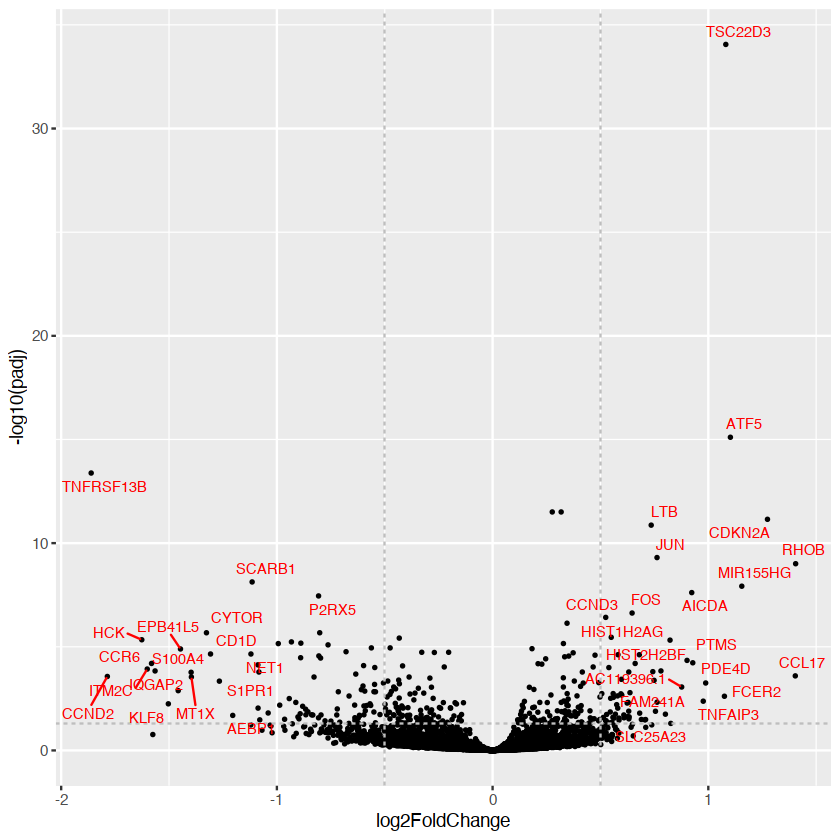

In [61]:
td <- VolcanoPlot(DE_scSHM)
td

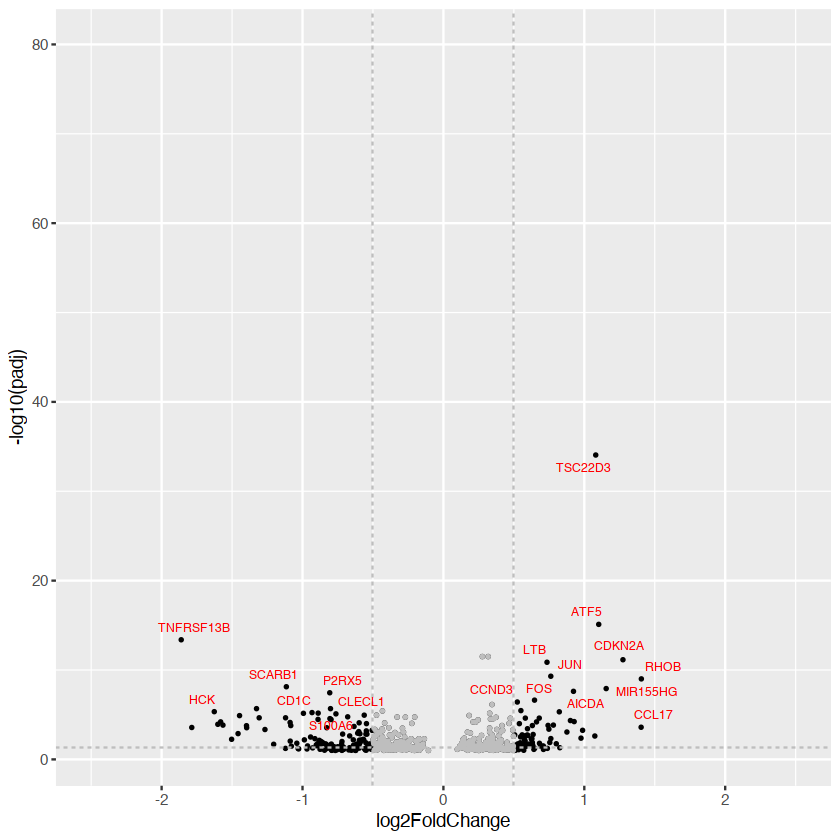

In [65]:
tc <- VolcanoPlotFixedFrame(DE_scSHM)
tc

In [21]:
#fig_save(td , filename = ("figs_paper/volcano_plot"), formats = c("pdf", "png"), width = 15, height =15, units = "cm", dpi = 320)

If within a row, all samples have zero counts, the baseMean column will be zero, and the log2 fold change estimates, p value and adjusted p value will all be set to NA.
If a row contains a sample with an extreme count outlier then the p value and adjusted p value will be set to NA. These outlier counts are detected by Cook’s distance. Customization of this outlier filtering and description of functionality for replacement of outlier counts and refitting is described below
If a row is filtered by automatic independent filtering, for having a low mean normalized count, then only the adjusted p value will be set to NA. Description and customization of independent filtering is described below

# Pathway analysis

### Convert genes names to Entrez Gene

In [70]:
DE_scSHM$entrez = mapIds(org.Hs.eg.db,
                     keys=DE_scSHM$rowname, 
                     column="ENTREZID",
                     keytype="SYMBOL",
                     multiVals="first")
DE_scSHM$name =   mapIds(org.Hs.eg.db,
                     keys=DE_scSHM$rowname, 
                     column="GENENAME",
                     keytype="SYMBOL",
                     multiVals="first")

'select()' returned 1:many mapping between keys and columns

'select()' returned 1:many mapping between keys and columns



In [74]:
## Remove any NA values (reduces the data by quite a bit)
DE_scSHM <- dplyr::filter(DE_scSHM, entrez != "NA")

## Remove any Entrez duplicates
DE_scSHM <- DE_scSHM[which(duplicated(DE_scSHM$entrez) == F), ]

In [75]:
head(DE_scSHM)

rowname,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,entrez,name
<chr>,<dbl>,<dbl>,<lgl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
NOC2L,0.20443502,-0.08896789,NA,0.34351007,0.55782365,0.8571909,26155,NOC2 like nucleolar associated transcriptional repressor
ISG15,0.16344130,0.04370001,NA,0.06344634,0.80113481,0.9468684,9636,ISG15 ubiquitin like modifier
SDF4,0.27516684,0.09342586,NA,0.48281171,0.48716800,0.8241168,51150,stromal cell derived factor 4
B3GALT6,0.07614066,-0.12168353,NA,0.20111520,0.65383213,0.8978180,126792,"beta-1,3-galactosyltransferase 6"
UBE2J2,0.21400524,0.30352841,NA,5.03493808,0.02486328,0.2266925,118424,ubiquitin conjugating enzyme E2 J2
INTS11,0.28239100,0.10069399,NA,0.67771816,0.41039367,0.7799269,54973,integrator complex subunit 11


In [76]:
DE_scSHM %>% filter(rowname == "AICDA")

rowname,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,entrez,name
<chr>,<dbl>,<dbl>,<lgl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
AICDA,0.2530296,0.9232035,NA,43.96458,3.52057e-11,2.430367e-08,57379,activation induced cytidine deaminase


### List of DNA repair genes

In [77]:
filename <- "input/names_genes_dna_repair.csv"
genes_names <- read.csv(filename)

In [78]:
# number of genes analysed
length(genes_names$gene)

[1] 66

In [79]:
DE_scSHM %>% filter(rowname %in% genes_names$gene, padj > 0.05)  %>% arrange(rowname) 

rowname,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,entrez,name
<chr>,<dbl>,<dbl>,<lgl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
ADAR,0.69661080,-0.120765916,NA,1.546629800,0.213663504,0.63146217,103,adenosine deaminase RNA specific
APEX1,0.90224802,0.019058067,NA,0.055939898,0.813037120,0.95062802,328,apurinic/apyrimidinic endodeoxyribonuclease 1
APEX2,0.15931711,-0.274763350,NA,2.715813659,0.099390452,0.46887842,27301,apurinic/apyrimidinic endodeoxyribonuclease 2
APTX,0.16780204,-0.031672971,NA,0.036006765,0.849505464,0.96076660,54840,aprataxin
FEN1,0.17371497,0.050852166,NA,0.109095458,0.741183386,0.92748688,2237,flap structure-specific endonuclease 1
HMGB1,6.68060249,0.050675260,NA,0.725720710,0.394294680,0.76934176,3146,high mobility group box 1
HMGB2,1.62041618,0.331429635,NA,9.248453845,0.002363191,0.05422902,3148,high mobility group box 2
LIG1,0.16666621,0.027613408,NA,0.033817361,0.854099666,0.96306047,3978,DNA ligase 1
MBD4,1.41159983,0.112118563,NA,2.248010768,0.133818597,0.53138101,8930,"methyl-CpG binding domain 4, DNA glycosylase"


## 1) Generally Applicable Gene-set Enrichment for Pathway Analysis: gage

In [80]:
kegg.sets.hs = kegg.sets.hs[sigmet.idx.hs]

In [81]:
# pathways not related with B cells
unvaluable_pathway <- c("hsa04966 Collecting duct acid secretion","hsa04971 Gastric acid secretion","hsa04914 Progesterone-mediated oocyte maturation",
                        "hsa04720 Long-term potentiation","hsa04916 Melanogenesis", "hsa04260 Cardiac muscle contraction",
                       "hsa04270 Vascular smooth muscle contraction","hsa04114 Oocyte meiosis","hsa04972 Pancreatic secretion","hsa04730 Long-term depression")

In [82]:
#remove those pathways from the list genes
kegg.sets.hs_filter <- discard(kegg.sets.hs, (names(kegg.sets.hs) %in% unvaluable_pathway ))

In [83]:
## Extract the foldchanges
foldchanges = DE_scSHM$log2FoldChange

## Name each fold change with the corresponding Entrez ID
names(foldchanges) = DE_scSHM$entrez
head(foldchanges)

26155        9636       51150      126792      118424       54973 
-0.08896789  0.04370001  0.09342586 -0.12168353  0.30352841  0.10069399

In [84]:
## Sort fold changes in decreasing order
foldchanges <- sort(foldchanges, decreasing = TRUE)

In [35]:
saveRDS(foldchanges, file = "foldchanges_v2.rds")

In [85]:
# Get the results
keggres = gage(foldchanges, gsets=kegg.sets.hs_filter, same.dir=TRUE)

# Look at both up (greater), down (less), and statatistics.
lapply(keggres, head,15)

,p.geomean,stat.mean,p.val,q.val,set.size,exp1
hsa03010 Ribosome,0.005941878,2.560897,0.005941878,0.5654103,86,0.005941878
hsa03440 Homologous recombination,0.018532100,2.172045,0.018532100,0.5654103,21,0.018532100
hsa00270 Cysteine and methionine metabolism,0.021312877,2.093900,0.021312877,0.5654103,22,0.021312877
hsa04350 TGF-beta signaling pathway,0.026269428,1.968622,0.026269428,0.5654103,41,0.026269428
hsa03030 DNA replication,0.033290258,1.870313,0.033290258,0.5654103,32,0.033290258
hsa00190 Oxidative phosphorylation,0.039587666,1.767812,0.039587666,0.5654103,101,0.039587666
hsa04110 Cell cycle,0.040509357,1.754353,0.040509357,0.5654103,98,0.040509357
hsa03430 Mismatch repair,0.044545631,1.750861,0.044545631,0.5654103,21,0.044545631
hsa00230 Purine metabolism,0.045123891,1.703186,0.045123891,0.5654103,92,0.045123891
hsa03050 Proteasome,0.046728123,1.704361,0.046728123,0.5654103,42,0.046728123


In [86]:
# Get the pathways
keggrespathways = data.frame(id=rownames(keggres$greater), keggres$greater) %>% 
  tbl_df() %>% 
  filter(row_number()<=5) %>% 
  .$id %>% 
  as.character()
keggrespathways

[1] "hsa03010 Ribosome"                          
[2] "hsa03440 Homologous recombination"          
[3] "hsa00270 Cysteine and methionine metabolism"
[4] "hsa04350 TGF-beta signaling pathway"        
[5] "hsa03030 DNA replication"

In [87]:
# Get the IDs.
keggresids = substr(keggrespathways, start=1, stop=8)
keggresids

[1] "hsa03010" "hsa03440" "hsa00270" "hsa04350" "hsa03030"

In [39]:
# # Define plotting function for applying later
# plot_pathway = function(pid) pathview(gene.data=foldchanges, pathway.id=pid, species="hsa", new.signature=FALSE)

# # plot multiple pathways (plots saved to disk and returns a throwaway list object)
# tmp = sapply(keggresids, function(pid) pathview(gene.data=foldchanges, pathway.id=pid, species="hsa")) #kegg.native = F, same.layer = F

In [88]:
# create list with all gene sets
gs <-
  lapply( list.files( "../SHM_in_the_act/input/msigdb_v2022.1.Hs_files_to_download_locally/msigdb_v2022.1.Hs_GMTs/" ),
            function( f ){
              qusage::read.gmt( paste0( "../SHM_in_the_act/input/msigdb_v2022.1.Hs_files_to_download_locally/msigdb_v2022.1.Hs_GMTs/", f ) )
            }
  ) %>%
  setNames( list.files( "../SHM_in_the_act/input/msigdb_v2022.1.Hs_files_to_download_locally/msigdb_v2022.1.Hs_GMTs/" ) )

# create rank: named vector       

r <- DE_scSHM$log2FoldChange %>% setNames( DE_scSHM$rowname )


# loop gene set collections
p <-
  rbindlist(
    lapply( names( gs ) %>% .[. %like% "c2.cp.kegg.v2022.1.Hs.symbols" ], #"h.all.v2022.1.Hs.symbols"
              function( g ){
                fgsea::fgsea(
                  # .gmt with pathways to analyzed
                  pathways = gs[[ g ]],
                  # my ranked list
                  stats    = r,
                  # min size of the gene set
                  minSize = 10,
                  # max size of the gene set
                  maxSize = 750,
                  eps = 0
                ) %>%
                  # add gene set name
                  mutate( gs = g ) %>%
                  filter( padj < 0.1 ) 

              } ) )
      

In [89]:
path <- gs[[names( gs ) %>% .[. %like% "c2.cp.kegg.v2022.1.Hs.symbols" ]]]

In [91]:
p #%>% filter(padj <= 0.05) %>% arrange(-NES)

pathway,pval,padj,log2err,ES,NES,size,leadingEdge,gs
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<list>,<chr>


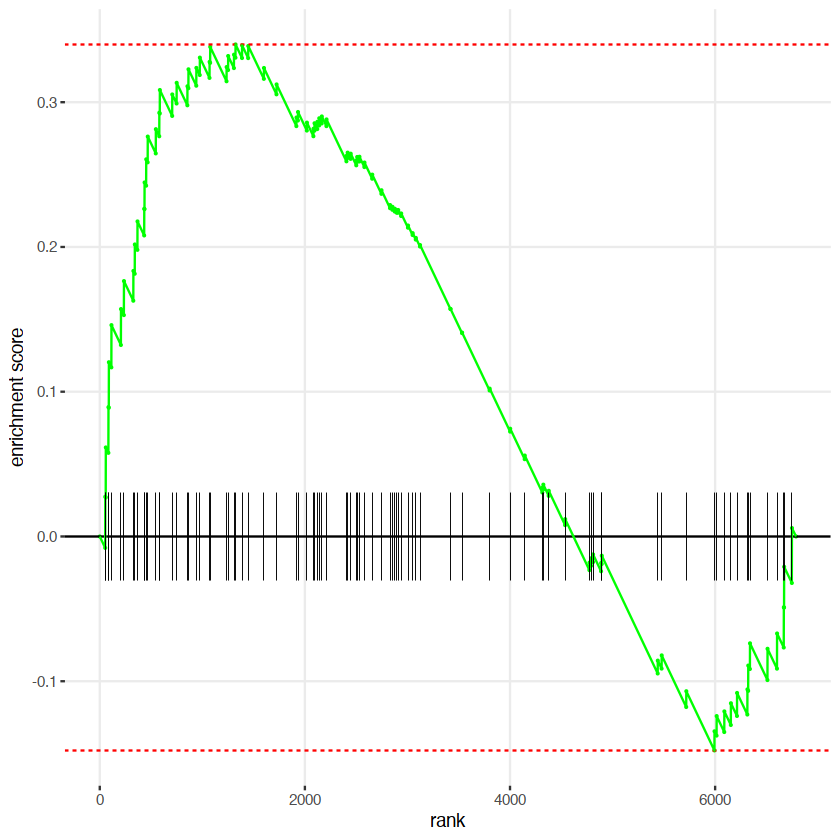

In [43]:
fgsea::plotEnrichment(path[["KEGG_CELL_CYCLE"]], r) 

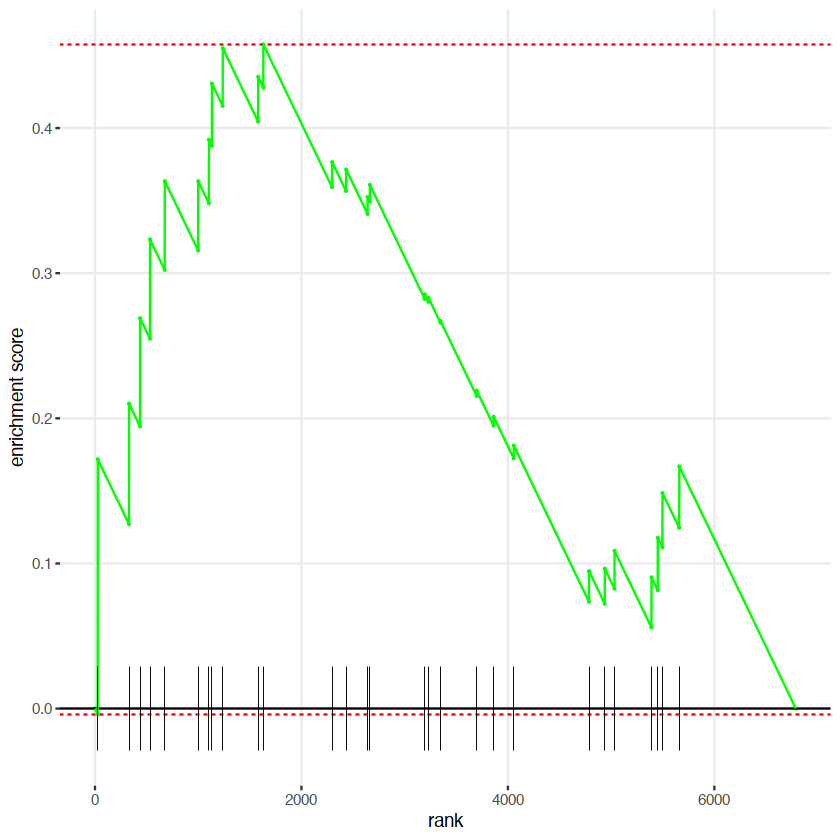

In [44]:
fgsea::plotEnrichment(path[["KEGG_BASE_EXCISION_REPAIR"]], r) 

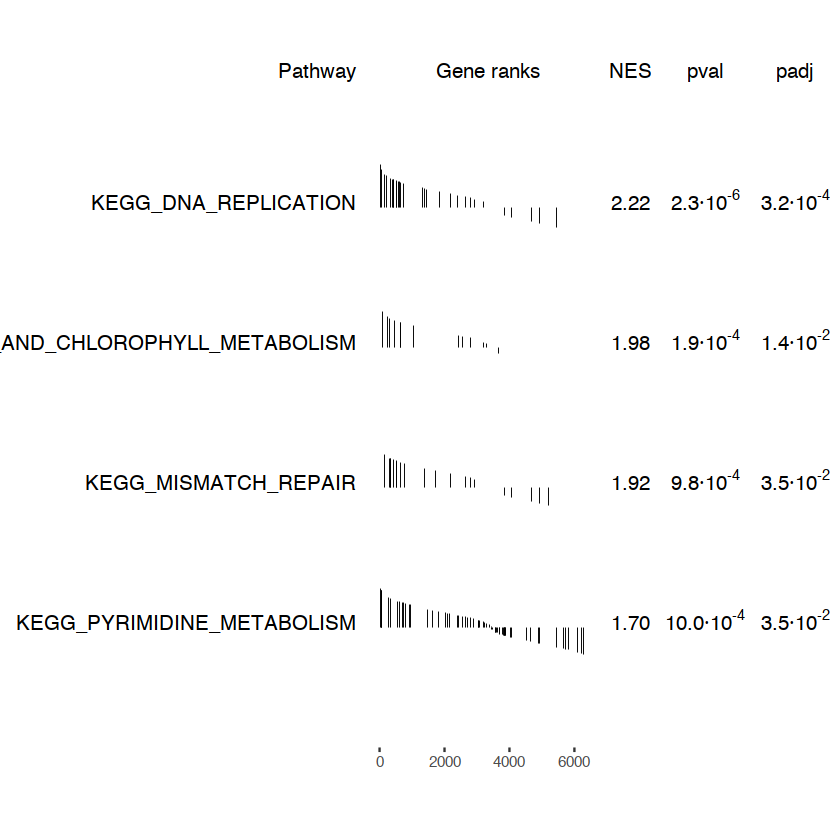

In [45]:
topPathways <- p %>% 
    top_n(20, wt=-padj) %>% 
    arrange(-NES) %>% 
    pull(pathway)

fgsea::plotGseaTable(path[topPathways], 
              r, 
              p, 
              gseaParam = 0.5)

## 3) KEGG Enrichment Analysis of a gene set : Cluster profiler tool

In [92]:
kegg_organism = "hsa"
kk2 = gseKEGG(geneList     = foldchanges,
               organism     = kegg_organism,
               minGSSize    = 3,
               maxGSSize    = 800,
               pvalueCutoff = 0.05,
               pAdjustMethod = "none",
               keyType       = "ncbi-geneid")

Reading KEGG annotation online: "https://rest.kegg.jp/link/hsa/pathway"...

Reading KEGG annotation online: "https://rest.kegg.jp/list/pathway/hsa"...

Reading KEGG annotation online: "https://rest.kegg.jp/conv/ncbi-geneid/hsa"...

preparing geneSet collections...

GSEA analysis...

leading edge analysis...

done...



In [93]:
kk2@result %>% filter(p.adjust <= 0.05) %>% arrange(-NES,qvalue) %>% head(.,11) #filter(Description %in% c("Histidine metabolism"))#

,ID,Description,setSize,enrichmentScore,NES,pvalue,p.adjust,qvalue,rank,leading_edge,core_enrichment
,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
hsa01524,hsa01524,Platinum drug resistance,53,0.4811795,1.854537,0.0004869065,0.0004869065,0.07636744,972,"tags=32%, list=12%, signal=29%",1029/27113/7155/1026/4193/7153/2944/2950/5290/672/5429/4437/4436/207/332/7157/4292
hsa04657,hsa04657,IL-17 signaling pathway,43,0.5039066,1.851506,0.0012489787,0.0012489787,0.08079647,710,"tags=21%, list=9%, signal=19%",6361/7128/3725/2353/4792/7186/7189/5970/3727
hsa03460,hsa03460,Fanconi anemia pathway,38,0.5023532,1.808891,0.0012878632,0.0012878632,0.08079647,1874,"tags=45%, list=23%, signal=35%",80233/5888/675/29089/2178/6118/672/5429/4292/55120/80010/2177/641/7398/51426/5395/545
hsa05210,hsa05210,Colorectal cancer,67,0.4251572,1.716369,0.0007550732,0.0007550732,0.07895151,1932,"tags=45%, list=23%, signal=35%",3725/2353/4609/27113/1026/5290/4437/4436/3845/207/5900/332/387/7157/4292/8312/324/2956/1643/5366/7040/4089/578/5605/3265/51426/5894/4087/5296/6198
hsa00270,hsa00270,Cysteine and methionine metabolism,30,0.4886706,1.650115,0.0108064290,0.0108064290,0.22198011,2115,"tags=47%, list=25%, signal=35%",4507/2730/2805/3939/7263/84245/262/10768/26227/4190/56267/2806/1786/58478
hsa05219,hsa05219,Bladder cancer,22,0.5214904,1.632293,0.0181192932,0.0181192932,0.24516942,1771,"tags=45%, list=21%, signal=36%",1029/4609/1026/4193/3845/7157/1019/5605/3265/5894
hsa03440,hsa03440,Homologous recombination,31,0.4792630,1.626681,0.0113224755,0.0113224755,0.22198011,3085,"tags=61%, list=37%, signal=39%",5888/675/6118/672/5932/5425/641/5424/10714/6742/11073/4683/5890/10111/51720/5889/7979/29086/580
hsa03430,hsa03430,Mismatch repair,21,0.5140642,1.591133,0.0186089964,0.0186089964,0.24516942,2245,"tags=62%, list=27%, signal=45%",6118/4437/4436/5425/4292/2956/5424/5982/5395/5983/10714/5985/6742
hsa03010,hsa03010,Ribosome,129,0.3412719,1.565233,0.0022133279,0.0022133279,0.11571434,3060,"tags=48%, list=37%, signal=31%",51264/124995/6143/100529239/51116/6175/79590/11222/6218/6150/64960/64963/219927/6132/9801/51187/6182/6129/6142/6125/200916/6155/6181/6159/9045/6176/6147/55168/9349/6193/6207/64969/51081/6128/64979/6202/6227/64928/6161/6139/6169/6170/6208/54460/25873/6222/6229/51073/65005/65008/51065/9553/64968/6201/6189/6205/6136/6188/6130/6141/6191/6165


In [94]:
kk2@result %>% filter(Description == "Base excision repair")

ID,Description,setSize,enrichmentScore,NES,pvalue,p.adjust,qvalue,rank,leading_edge,core_enrichment
<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>


In [98]:
da <- dotplot(kk2, showCategory = 20, title = "Enriched Pathways" , split=".sign") + facet_grid(.~.sign)
da

ERROR: Error in as_white_ref(white): lazy-load database '/usr/local/Cellar/r/4.2.2_1/lib/R/library/farver/R/farver.rdb' is corrupt


In [101]:
selected_pathways <- c("DNA replication","Fanconi anemia pathway","Mismatch repair", "Cell cycle",#neg
                       "Rheumatoid arthritis","NF-kappa B signaling pathway","JAK-STAT signaling pathway",
                      "Cytokine-cytokine receptor interaction","NOD-like receptor signaling pathway","Transcriptional misregulation in cancer",
                      "Base excision repair","Fc gamma R-mediated phagocytosis","MicroRNAs in cancer","Lysosome",
                       "TGF-beta signaling pathway", "ECM-receptor interaction","Platinum drug resistance") #pos

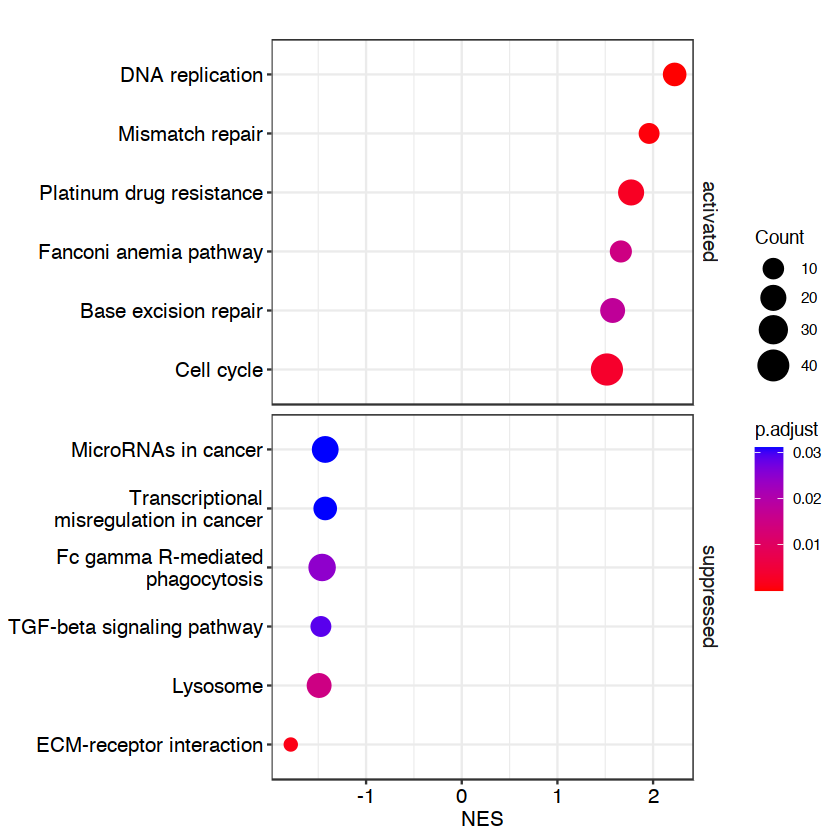

In [51]:
dt <- dotplot(kk2, x= "NES", showCategory = selected_pathways , split=".sign") + facet_grid(.sign~.,scales = "free")+
#  theme_bw() +
  theme(strip.text = element_text(
    size = 12),strip.background = element_rect(fill = "white", colour = NA),) 
dt

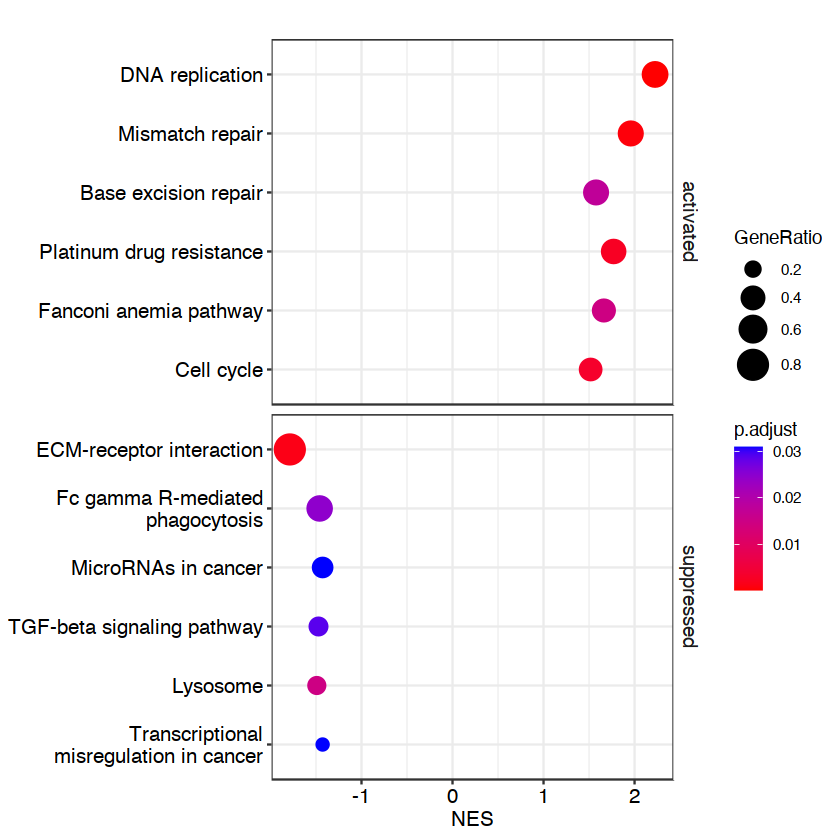

In [52]:
dt <- dotplot(kk2,x= "NES", size = "GeneRatio",showCategory = selected_pathways , split=".sign", orderBy = "GeneRatio") + facet_grid(.sign~.,scales = "free")+
#  theme_bw() +
  theme(strip.text = element_text(
    size = 12),strip.background = element_rect(fill = "white", colour = NA),) 
dt

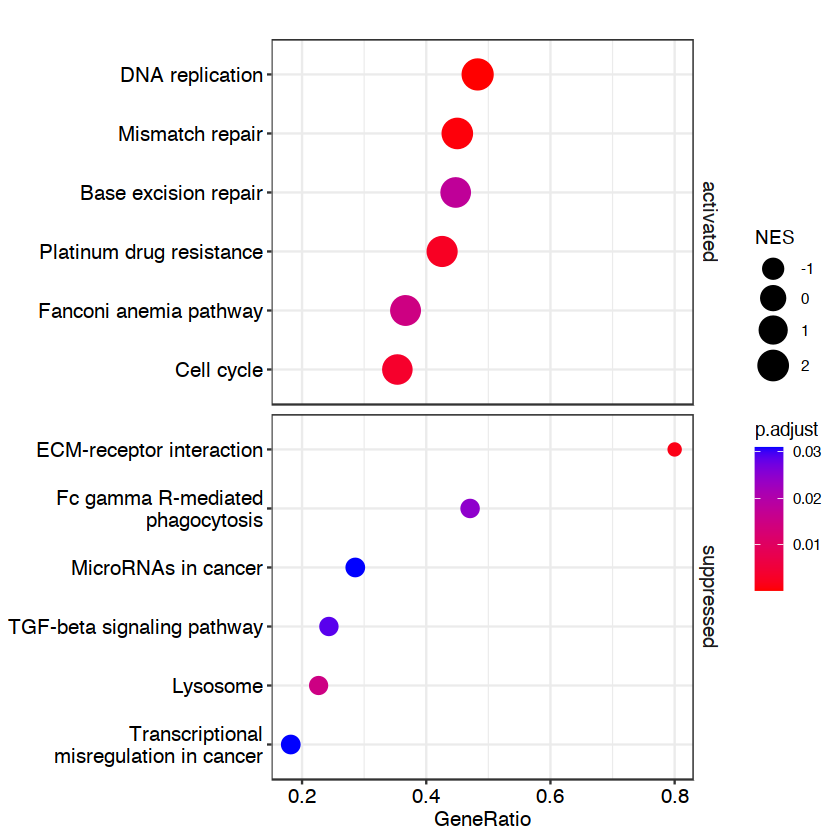

In [53]:
dt <- dotplot(kk2,x= "GeneRatio", size ="NES" ,showCategory = selected_pathways , split=".sign", orderBy = "GeneRatio") + facet_grid(.sign~.,scales = "free")+
#  scale_size_continuous(range = c(-1,2.2), breaks = seq(-1, 2.2, by = 0.8)) +
  theme(strip.text = element_text(
    size = 12),strip.background = element_rect(fill = "white", colour = NA),) 
dt

In [54]:
fig_save(dt , filename = ("figs_paper/dotplot_pathways_NES"), formats = c("pdf", "png"), width = 15, height= 20, units = "cm", dpi = 320)

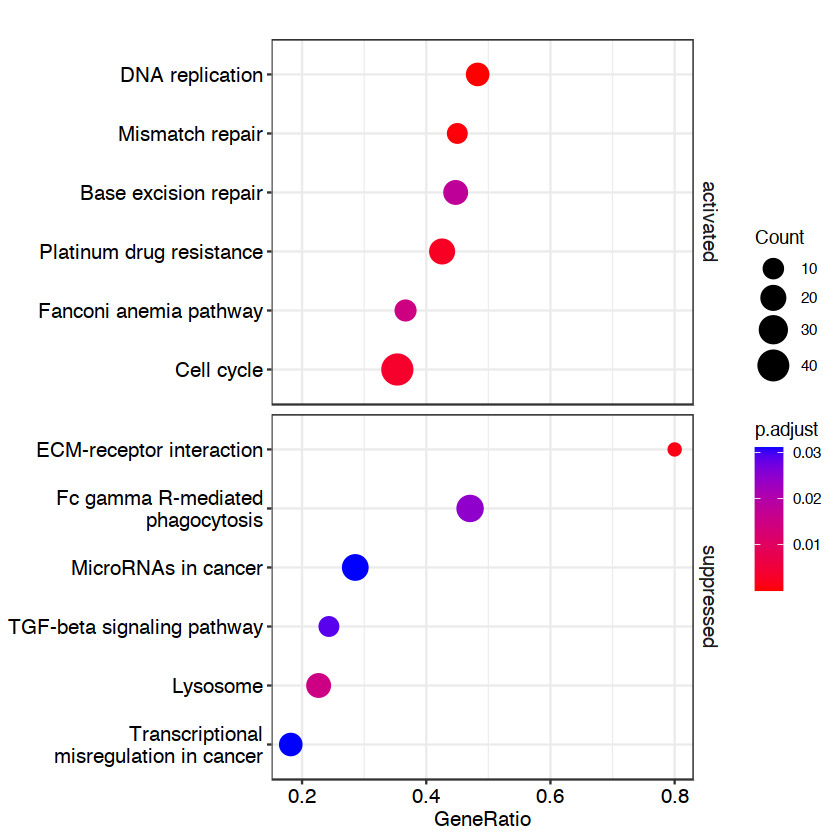

In [55]:
dt <- dotplot(kk2, showCategory = selected_pathways , split=".sign") + facet_grid(.sign~.,scales = "free")+
#  theme_bw() +
  theme(strip.text = element_text(
    size = 12),strip.background = element_rect(fill = "white", colour = NA),) 
dt

In [56]:
#fig_save(dt , filename = ("figs_paper/dotplot_pathways"), formats = c("pdf", "png"), width = 15, height =20, units = "cm", dpi = 320)

In [57]:
# # Get the pathways
# keggrespathways = kk2 %>% 
#   tbl_df() %>% 
# #  filter(Description %in% selected_pathways, ID != 'hsa01100') %>% 
#   filter(row_number()<=5) %>%
#   .$ID %>% 
#   as.character()
# keggrespathways

In [58]:
# Get the IDs.
# keggresids = substr(keggrespathways, start=1, stop=8)
# keggresids

keggresids = c("hsa03030","hsa03460","hsa03430","hsa03410")
keggresids

[1] "hsa03030" "hsa03460" "hsa03430" "hsa03410"

In [59]:
# Define plotting function for applying later
plot_pathway = function(pid) pathview(gene.data=foldchanges, pathway.id=pid, species="hsa", new.signature=FALSE)

# plot multiple pathways (plots saved to disk and returns a throwaway list object)
tmp = sapply(keggresids, function(pid) pathview(gene.data=foldchanges, pathway.id=pid, species="hsa",
                                                limit= 2, #limit= list(gene=max(abs(foldchanges)), cpd=1),
                                               na.col ="grey",
                                                   low=list(gene="#ffa700"),
                                                    mid=list(gene="#4ac4aa"),
                                                    high=list(gene="#198bdc"))) #kegg.native = F, same.layer = F

'select()' returned 1:1 mapping between keys and columns

Info: Working in directory /Users/julieta/Library/CloudStorage/GoogleDrive-julieta.sepulveda@umag.cl/My Drive/bioinformatics/data_analysis/SHM_in_the_act

Info: Writing image file hsa03030.pathview.png

'select()' returned 1:1 mapping between keys and columns

Info: Working in directory /Users/julieta/Library/CloudStorage/GoogleDrive-julieta.sepulveda@umag.cl/My Drive/bioinformatics/data_analysis/SHM_in_the_act

Info: Writing image file hsa03460.pathview.png

Info: some node width is different from others, and hence adjusted!

'select()' returned 1:1 mapping between keys and columns

Info: Working in directory /Users/julieta/Library/CloudStorage/GoogleDrive-julieta.sepulveda@umag.cl/My Drive/bioinformatics/data_analysis/SHM_in_the_act

Info: Writing image file hsa03430.pathview.png

'select()' returned 1:1 mapping between keys and columns

Info: Working in directory /Users/julieta/Library/CloudStorage/GoogleDrive-julieta.sepulve

#### generate a df from every pathway of interest

In [60]:
# #pathways
# paths <-c("KEGG_CELL_CYCLE","KEGG_MAPK_SIGNALING_PATHWAY")#,"VEGF signaling pathway",
# #          "Ribosome", "Antigen processing and presentation", "Cytokine-cytokine receptor interaction")

# # create an empty list to store the data frames
# df_list <- list()

# for (i in paths) {
#     i$entrez <- mapIds(org.Hs.eg.db,
#                      keys=path$i, 
#                      column="ENTREZID",
#                      keytype="SYMBOL",
#                      multiVals="first") %>% data.frame() %>% pull(.)
    
#     df <- DE_scSHM %>% filter(entrez %in% i$entrez)
#     # use a unique name as the index of the list
#     df_list[[paste0("df_", i)]] <- df
# }

In [61]:
# #pathways
# paths <-c("KEGG_CELL_CYCLE","KEGG_MAPK_SIGNALING_PATHWAY")

# KEGG_CELL_CYCLE$entrez <- mapIds(org.Hs.eg.db,
#                      keys=path$KEGG_CELL_CYCLE, 
#                      column="ENTREZID",
#                      keytype="SYMBOL",
#                      multiVals="first") %>% data.frame() %>% pull(.)

# KEGG_CELL_CYCLE$entrez

# df <- DE_scSHM %>% filter(entrez %in% KEGG_CELL_CYCLE$entrez)

In [62]:
str(path$KEGG_MAPK_SIGNALING_PATHWAY)

 chr [1:267] "JUN" "MEF2C" "ELK4" "ELK1" "JUND" "GADD45B" "MAP3K20" "STMN1" ...


In [63]:
# create an empty list to store the data frames
df_list <- list()

for (i in keggresids) {
    xc <- kk2@result %>% filter(ID == i) %>% mutate(genes = gsub("/", ",", core_enrichment)) %>% pull(genes)
    my_vector <- strsplit(xc, ",")[[1]] 
    df <- DE_scSHM %>% filter(entrez %in% my_vector)
    # use a unique name as the index of the list
    df_list[[paste0("df_", i)]] <- df
}

In [64]:
# assign each data frame to a separate variable
for (i in names(df_list)) {
  assign(i, df_list[[i]])
}

In [102]:
#set.seed(123)
x2 = pairwise_termsim(kk2)
xc <- emapplot(x2, showCategory = selected_pathways,group_category = T,group_legend = T,nCluster = 3, layaout= 'gem')
xc

ERROR: Error in melt.matrix(w): lazy-load database '/usr/local/Cellar/r/4.2.2_1/lib/R/library/plyr/R/plyr.rdb' is corrupt


In [66]:
options(repr.plot.width = 8, repr.plot.height = 6, repr.plot.res = 300)
set.seed(31)
x2 = pairwise_termsim(kk2)
xc <- emapplot(
    x2,
    showCategory = selected_pathways,
    cluster.params = list(
        cluster=TRUE,
        n=3,
        legend=TRUE
    ),
    layout.params = list(
        layout = "gem"
    )
)

pdf(file = paste0("figs_paper/emapplot.pdf"), 8.8, 5) 
print(xc) 
dev.off() 

pdf 
  2

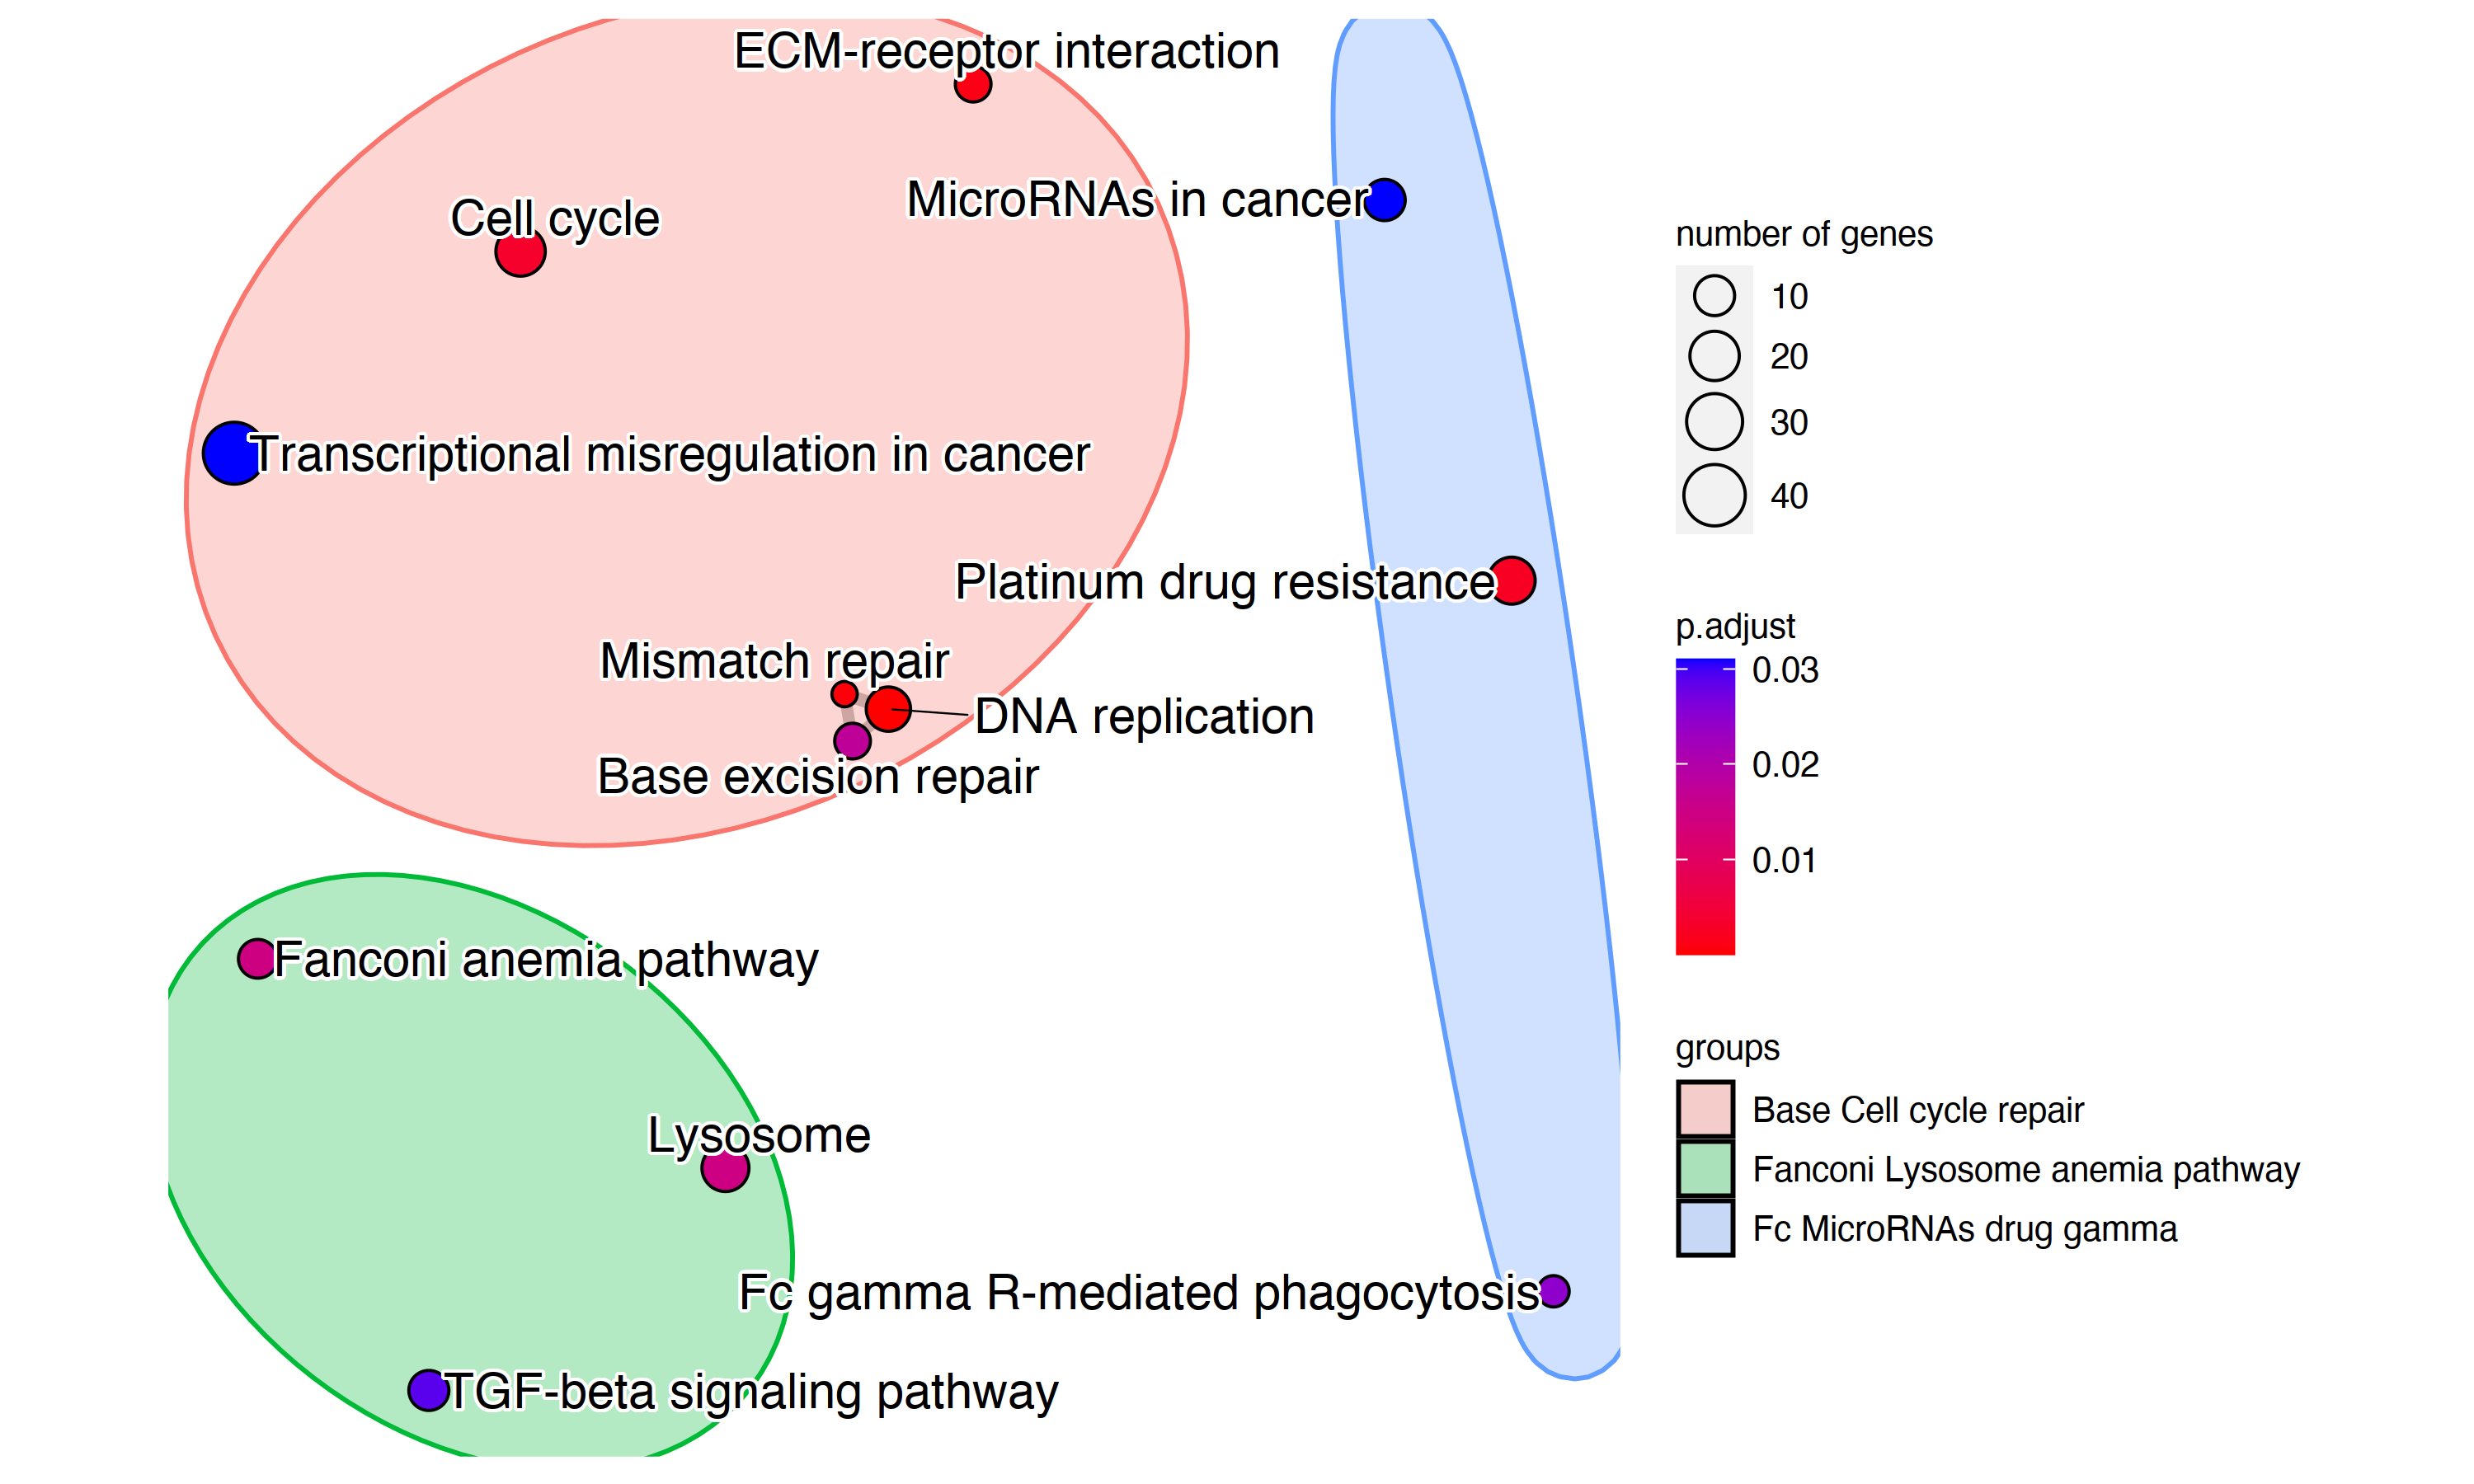

In [67]:
options(repr.plot.width = 10, repr.plot.height = 6, repr.plot.res = 300)
#set.seed(31)
x2 = pairwise_termsim(kk2)
xc <- emapplot(
    x2,
    showCategory = selected_pathways,
    cluster.params = list(
        cluster=TRUE,
        n=3,
        legend=TRUE
    ),
    layout.params = list(
        layout = "gem"
    )
)

#pdf(file = paste0("figs_paper/emapplot.pdf"), 8.8, 5) 
print(xc) 
#dev.off()

In [68]:
fig_save(xc , filename = ("figs_paper/emapplot"), formats = c("pdf", "png"), width =20, height =20, units = "cm", dpi = 320)

Picking joint bandwidth of 0.116



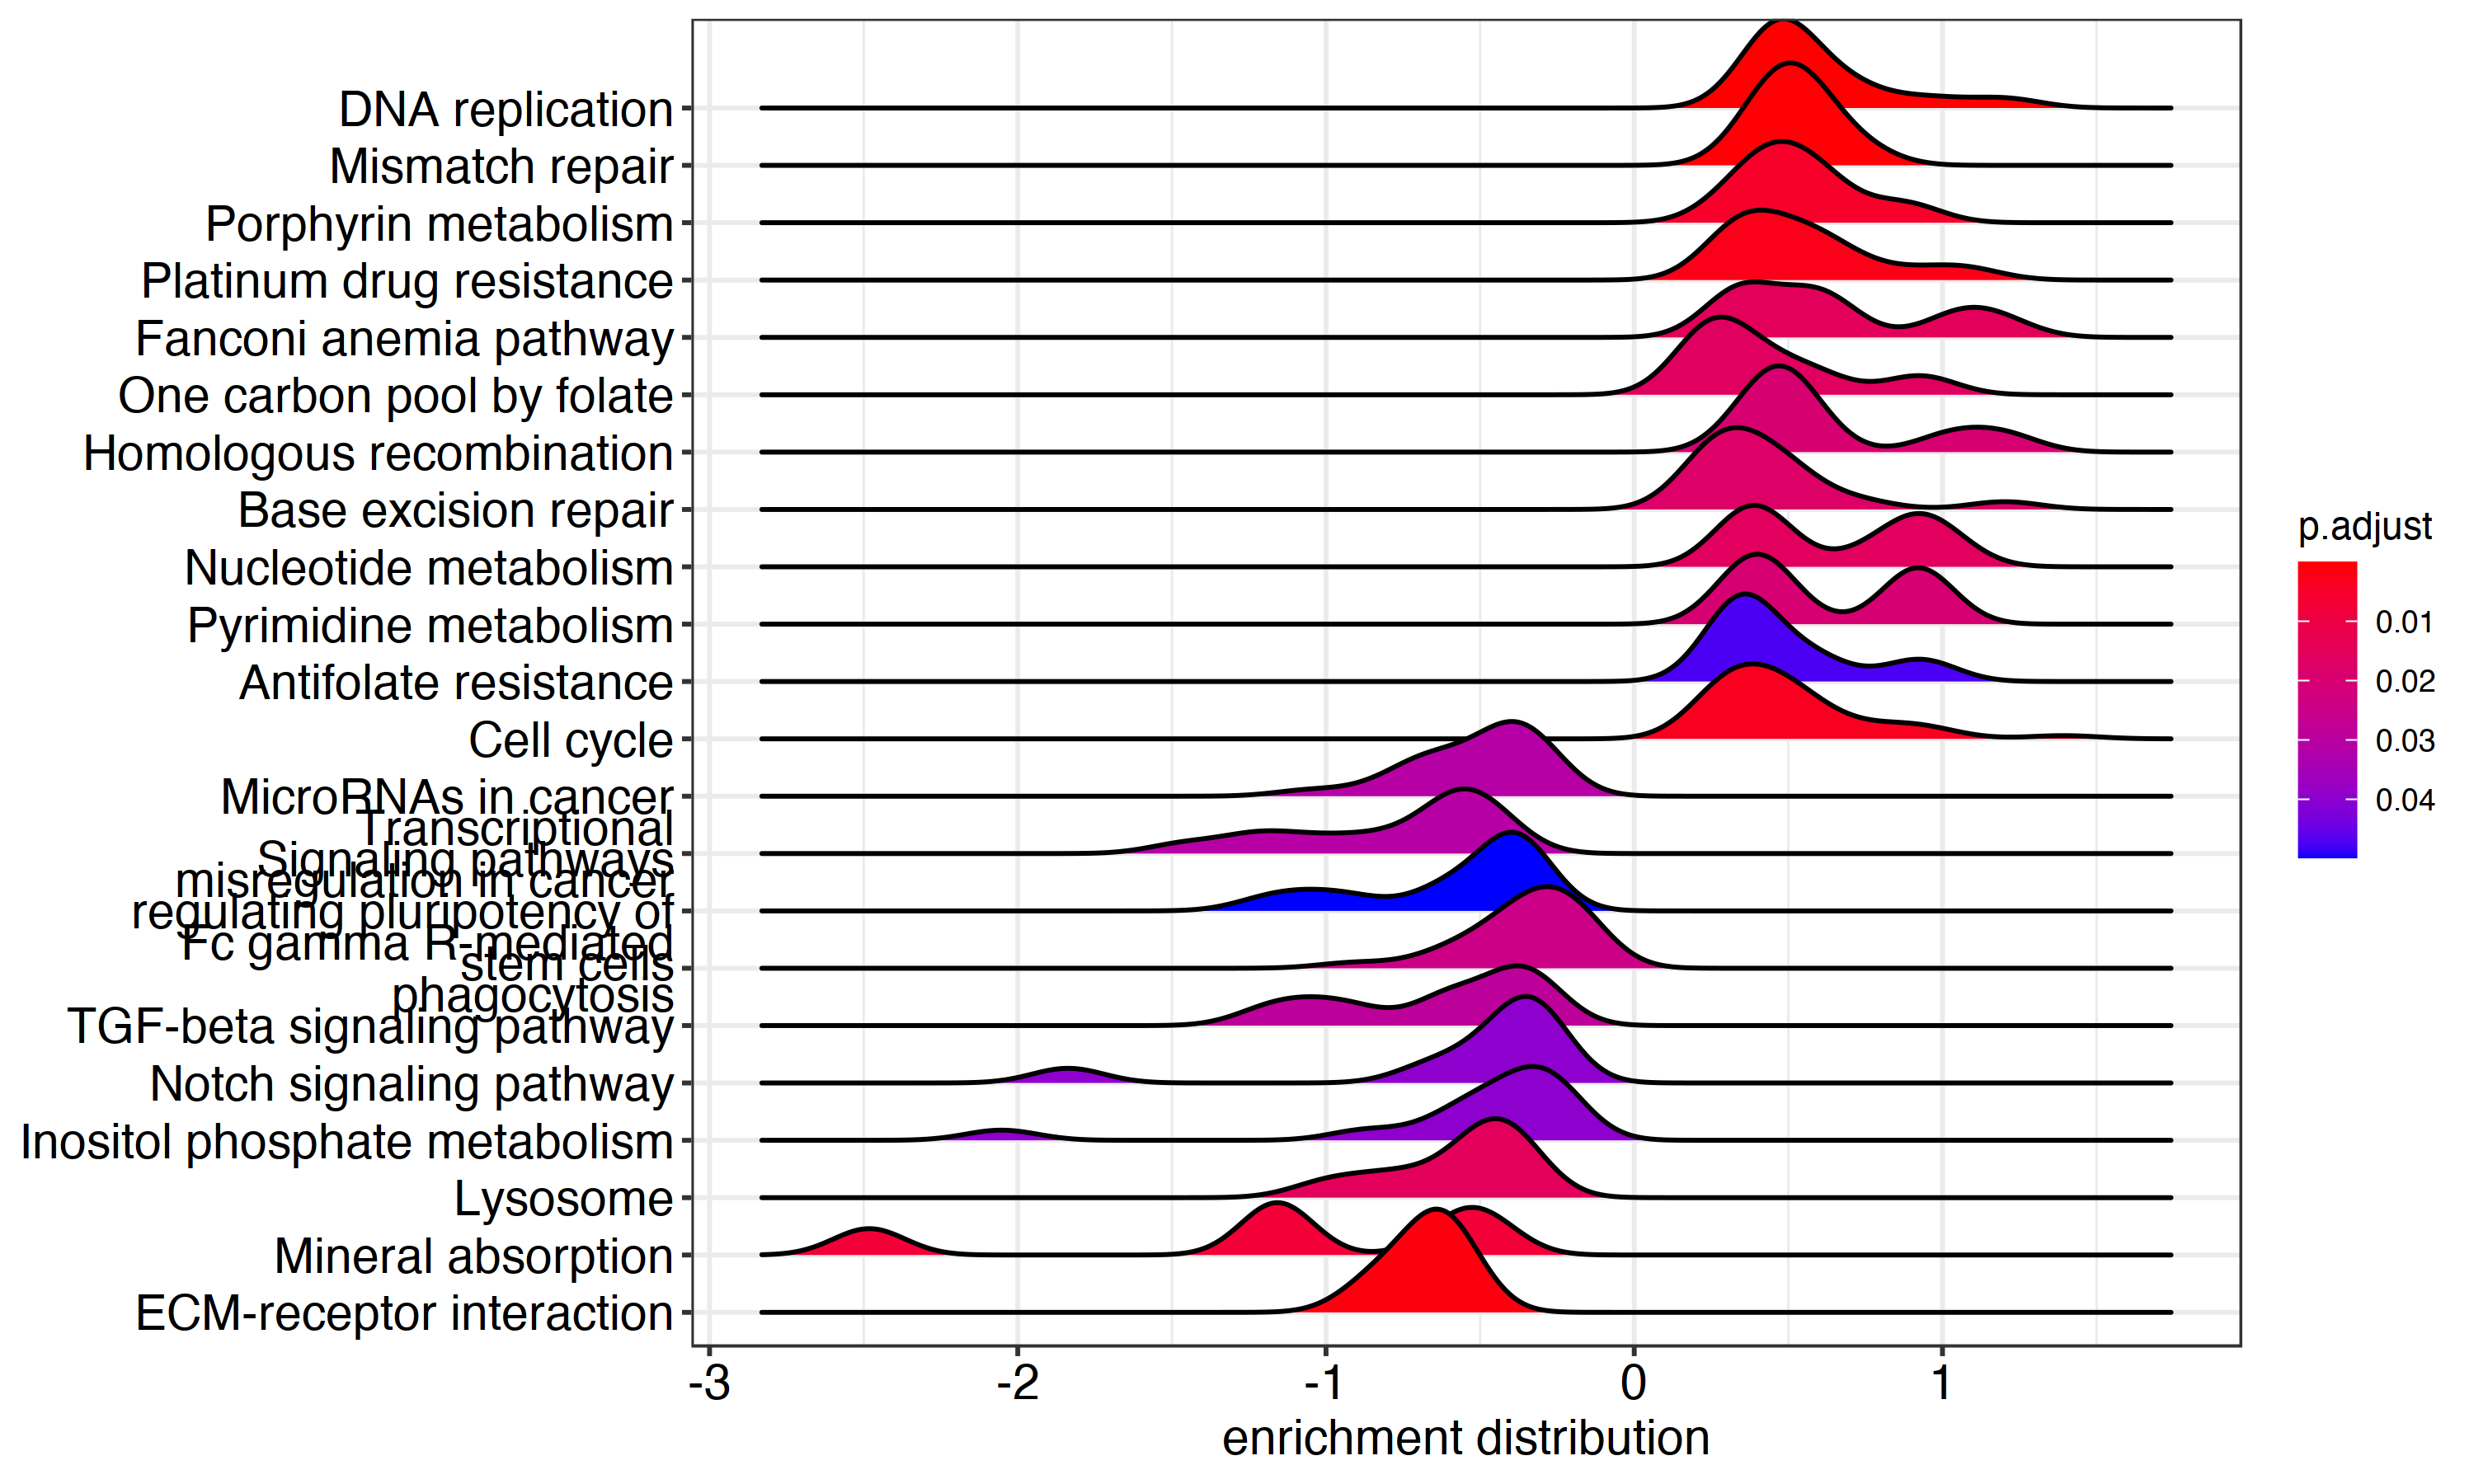

In [69]:
ridgeplot(kk2) + labs(x = "enrichment distribution")

In [70]:
library("DEGreport")

## Volcano plot lindo

### List of DNA repair genes

In [9]:
filename <- "input/names_genes_dna_repair.csv"
genes_names <- read.csv(filename)

In [10]:
# number of genes analysed
length(genes_names$gene)

[1] 66

### Results without batch correction

In [5]:
# without batch correcttion
dds <- readRDS("output/dds_v2.rds")

In [6]:
dds@assays

An object of class "SimpleAssays"
Slot "data":
List of length 2
names(2): counts mu


In [7]:
summary(results(dds))


out of 7026 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 2114, 30%
LFC < 0 (down)     : 1657, 24%
outliers [1]       : 0, 0%
low counts [2]     : 0, 0%
(mean count < 0)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



In [13]:
# Turn the results object into a tibble for use with tidyverse functions
DE_scSHM <- results(dds) %>%
        data.frame() %>%
        rownames_to_column(var="rowname") %>%
        as_tibble()

# Check results output
head(DE_scSHM)

rowname,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
<chr>,<dbl>,<dbl>,<lgl>,<dbl>,<dbl>,<dbl>
NOC2L,0.22709129,-0.64119852,NA,22.57685947,2.087645e-06,1.092980e-05
ISG15,0.08298455,0.39323609,NA,4.37446654,3.654219e-02,7.226159e-02
SDF4,0.29567413,-0.46982878,NA,15.54192836,8.203177e-05,3.176618e-04
UBE2J2,0.25988836,-0.52776511,NA,18.24471358,1.986359e-05,8.695424e-05
INTS11,0.27118955,-0.37220543,NA,9.95549548,1.615226e-03,4.718743e-03
CPTP,0.10802095,0.04355817,NA,0.05901141,8.080774e-01,8.633747e-01


In [19]:
DE_scSHM %>% filter(rowname %in% genes_names$gene) %>%
  # summarise(
  #   min_value = min(log2FoldChange, na.rm = TRUE),
  #   max_value = max(log2FoldChange, na.rm = TRUE)
  # )

min_value,max_value
<dbl>,<dbl>
-1.868196,1.407575


In [15]:
DE_scSHM %>% filter(rowname == "AICDA")

min_value,max_value
<dbl>,<dbl>
-5.240797,4.205954


In [17]:
DE_scSHM %>% filter(rowname %like% "POL")

rowname,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
<chr>,<dbl>,<dbl>,<lgl>,<dbl>,<dbl>,<dbl>
POLR3C,0.16890304,-0.27767511,NA,3.47833453,6.224816e-02,1.135399e-01
POLR3GL,0.38901087,-0.50706043,NA,23.61757885,1.218706e-06,6.642846e-06
POLE4,0.24218590,0.40907403,NA,13.87288710,1.982116e-04,7.040620e-04
POLR2D,0.11877909,0.28917400,NA,3.58804096,5.826662e-02,1.073365e-01
POLR2H,0.20329074,-0.03763391,NA,0.08583875,7.695502e-01,8.333631e-01
POLR2B,0.24102898,-0.13955635,NA,1.27509674,2.588783e-01,3.627601e-01
PRIMPOL,0.07223688,0.04998601,NA,0.05622685,8.125739e-01,8.671240e-01
POLK,0.09923974,0.41802654,NA,5.46939574,1.939977e-02,4.171561e-02
POLR1C,0.09402527,0.23966343,NA,1.76001440,1.846961e-01,2.763950e-01


In [18]:
DE_scSHM %>% filter(rowname == "AICDA")

rowname,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
<chr>,<dbl>,<dbl>,<lgl>,<dbl>,<dbl>,<dbl>
AICDA,0.1137483,1.407575,NA,96.30132,1.734717e-22,4.56484e-21


In [16]:
DE_scSHM %>% filter(rowname == "AICDA")

rowname,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
<chr>,<dbl>,<dbl>,<lgl>,<dbl>,<dbl>,<dbl>
AICDA,0.2535665,0.9240602,NA,65.0948,1.141899e-41,5.552724e-41


In [38]:
genes_volcano <- DE_scSHM$rowname[which(names(keyvals) %in% c("Upregulated", "Downregulated"))]

In [39]:
filtered_genes <- genes_volcano[genes_volcano %in% genes_names$gene]

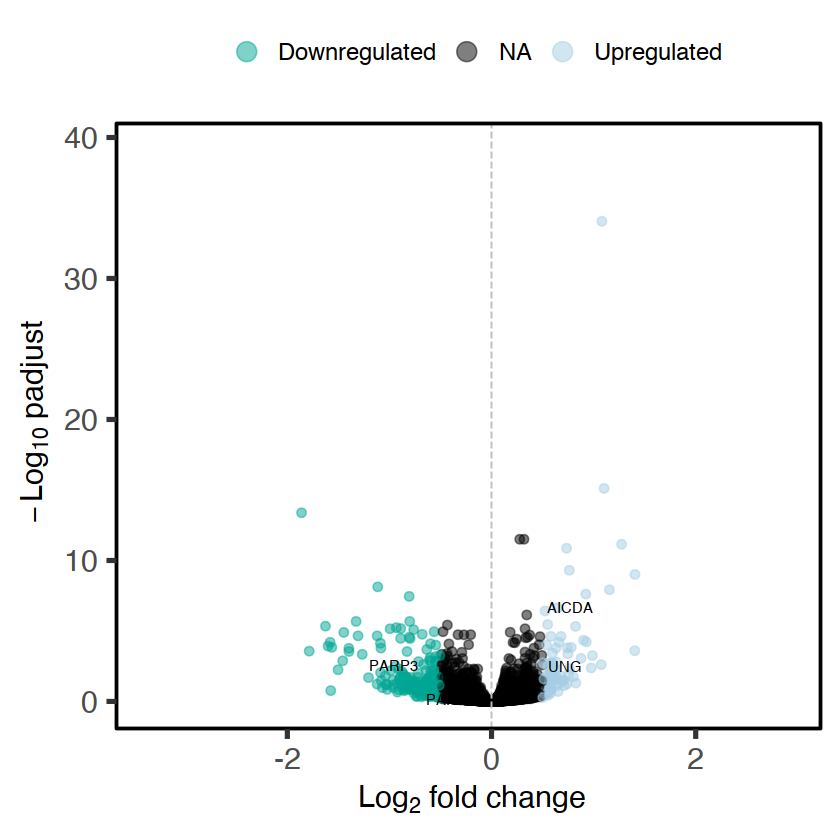

In [64]:
# create custom key-value pairs for high, low, mid expression
keyvals <- rep("black", nrow(DE_scSHM))
names(keyvals) <- rep("NA", nrow(DE_scSHM))

keyvals[which(DE_scSHM$log2FoldChange > 0.5)] <- "#a6cee3"
names(keyvals)[which(DE_scSHM$log2FoldChange > 0.5)] <- "Upregulated"

keyvals[which(DE_scSHM$log2FoldChange < -0.5)] <- "#00A693"
names(keyvals)[which(DE_scSHM$log2FoldChange < -0.5)] <- "Downregulated"

ev <- EnhancedVolcano(DE_scSHM,lab = DE_scSHM$rowname, x = "log2FoldChange",y = "padj",
                       pCutoff = F,
                       FCcutoff = F,
                            border = "full",
#        selectLab = filtered_genes,    #DE_scSHM$rowname[which(names(keyvals) %in% c("Upregulated", "Downregulated"))],
        borderWidth = 0.8,borderColour = "black",
        labSize = 5,
#        boxedLabels = TRUE,
        gridlines.major = FALSE,

        gridlines.minor = FALSE,
#        boxedLabels = TRUE,
 #       cutoffLineType = NULL,
        cutoffLineCol = "grey",
        col = c("#a6cee3","#1f78b4" ,"#b2df8a" ,"#33a02c"),
        title= NULL,
        subtitle=NULL,
        colCustom = keyvals,
        caption = NULL,
        ylab = bquote(~-Log[10] ~ padjust)) +
geom_text_repel(
  data = DE_scSHM %>% filter(rowname %in% filtered_genes),
  aes(x = log2FoldChange, y = -log10(padj), label = rowname),
  size = 3,
  max.overlaps = Inf
)


ev

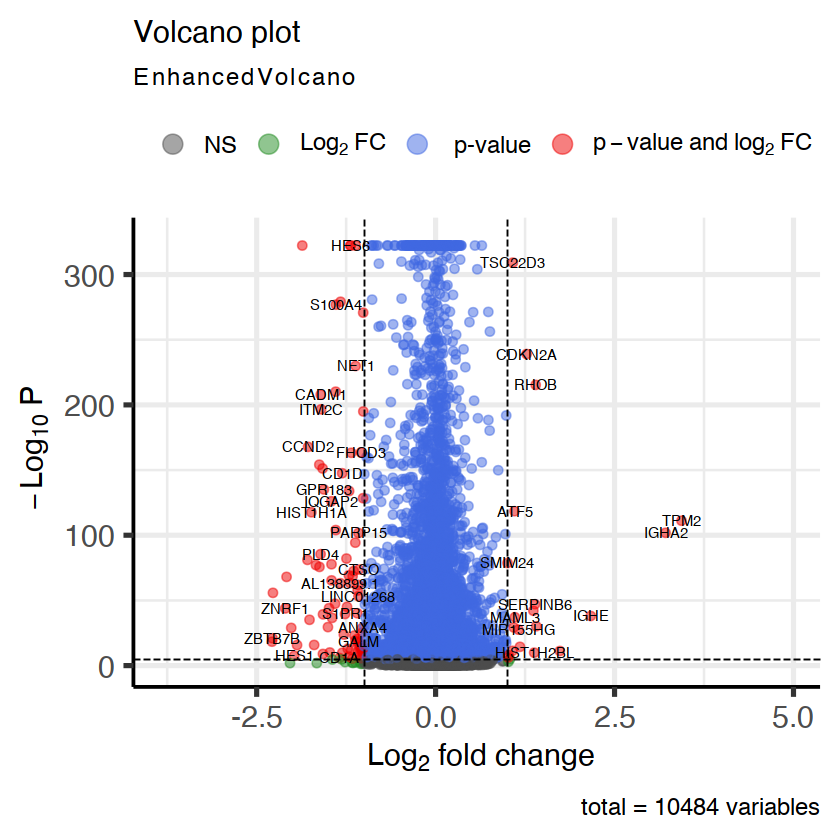

In [41]:

ev <- EnhancedVolcano(
  DE_scSHM,
  lab = DE_scSHM$rowname,
  x = "log2FoldChange",
  y = "padj",
#  selectLab = filtered_genes,
  labSize = 3
) #+
# geom_text_repel(
#   data = DE_scSHM %>% filter(rowname %in% filtered_genes),
#   aes(x = log2FoldChange, y = -log10(padj), label = rowname),
#   size = 3,
#   max.overlaps = Inf
# )

ev

In [28]:
fig_save(ev , filename = ("figs_paper/test_volcano_plot"), formats = c("pdf", "png"), width = 20, height =12, units = "cm", dpi = 320)

In [29]:
#fig_save(ev , filename = ("figs_paper/volcano_plot"), formats = c("pdf", "png"), width = 20, height =12, units = "cm", dpi = 320)

## Another plotting for DE

In [7]:
results(dds)

log2 fold change (MLE): condition2 
LRT p-value: '~ batch + condition' vs '~ 1' 
DataFrame with 7026 rows and 6 columns
           baseMean log2FoldChange     lfcSE      stat       pvalue
          <numeric>      <numeric> <logical> <numeric>    <numeric>
NOC2L     0.2270913     -0.0733157        NA   9.50315  4.11524e-13
ISG15     0.0829845     -0.0886571        NA  13.35317  3.11665e-19
SDF4      0.2956741      0.7077189        NA  12.68068  3.70697e-18
UBE2J2    0.2598884      0.0431379        NA  10.69573  5.36221e-15
INTS11    0.2711895     -0.0370490        NA   6.14246  6.68334e-08
...             ...            ...       ...       ...          ...
TUG1      0.0916119       0.177524        NA   7.70805  2.64154e-10
MRTFA     0.1776842       0.637385        NA  13.43613  2.29563e-19
LINC01278 0.0578575       0.762119        NA  11.99861  4.54510e-17
SEPTIN6   1.0435942      -0.306244        NA  75.04192 5.18189e-116
PRKY      0.0637506      -1.542756        NA  11.11566  1.15559e

In [9]:
# Set thresholds
padj_cutoff <- 0.05

# Subset the significant results
sig_res <- filter(DE_scSHM, padj < padj_cutoff) %>%
        dplyr::arrange(padj)

# Check significant genes output
head(sig_res)

rowname,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
<chr>,<dbl>,<dbl>,<lgl>,<dbl>,<dbl>,<dbl>
DNER,0.1386676,-0.22631975,NA,418.0380,0,0
MTRNR2L12,1.2900551,0.20980774,NA,1489.5356,0,0
DUSP1,0.5069365,0.39375703,NA,256.3425,0,0
GMDS,0.3586152,-0.62927631,NA,303.4613,0,0
HLA-C,11.7543740,0.04704688,NA,259.5537,0,0
HLA-DQB1,4.0674597,0.07804472,NA,335.8776,0,0


In [15]:
ei <- d %>% rownames_to_column(var="samplename") %>% mutate(samplename = str_replace(samplename,"-",".")) 

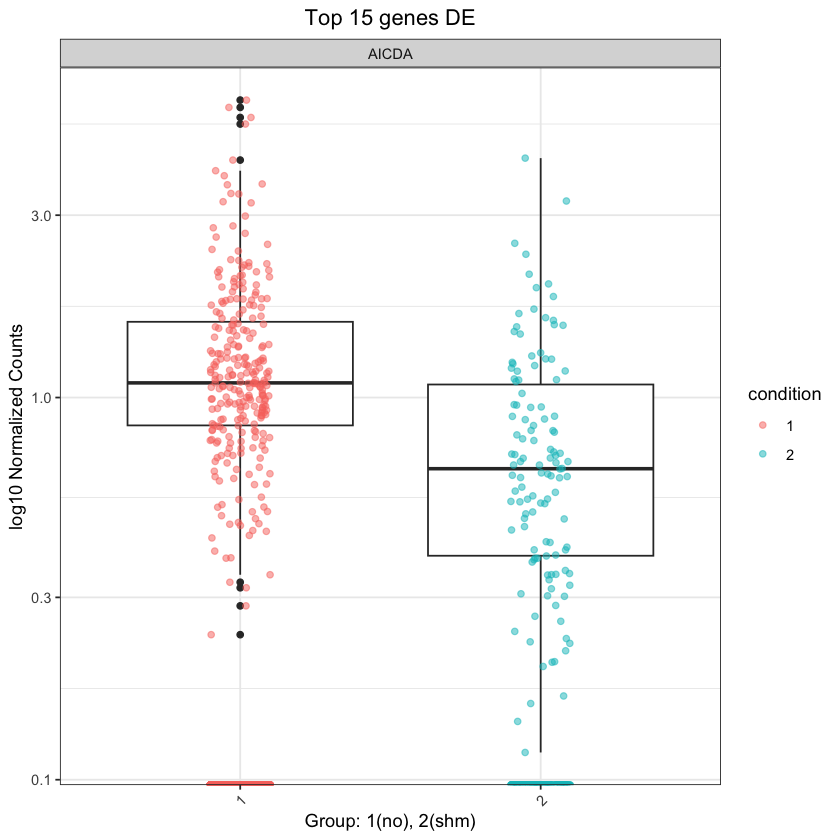

In [28]:
## ggplot of top genes
normalized_counts <- counts(dds, 
                            normalized = TRUE)

# Order results by padj values
top20_sig_genes <- sig_res %>%
        dplyr::arrange(padj) %>%
        dplyr::pull(rowname) %>%
        head(n=15)

#top20_sig_genes <- c("JUND",'LAPTM5','CD74','IL32','RNF213','TSC22D3','PEBP1','FTL','CD79A','IRF1','HLA-DRB1')

top20_sig_genes <- c("AICDA")


top20_sig_norm <- data.frame(normalized_counts) %>%
        rownames_to_column(var = "gene") %>%
        dplyr::filter(gene %in% top20_sig_genes)

gathered_top20_sig <- top20_sig_norm %>%
        gather(colnames(top20_sig_norm)[2:length(colnames(top20_sig_norm))], key = "samplename", value = "normalized_counts")
        
gathered_top20_sig <- inner_join(ei[, c("samplename", "condition" )], gathered_top20_sig, by = c("samplename"))

## plot using ggplot2
sii <- ggplot(gathered_top20_sig) +
     geom_boxplot(aes(x=condition, y=normalized_counts)) +
        geom_point(aes(x = condition, 
                       y = normalized_counts, 
                       color = condition), 
                   position=position_jitter(w=0.1,h=0), alpha=.5) +
        scale_y_log10() +
        xlab("Group: 1(no), 2(shm)") +
        ylab("log10 Normalized Counts") +
        ggtitle("Top 15 genes DE") +
        theme_bw() +
        theme(axis.text.x = element_text(angle = 45, hjust = 1)) + 
        theme(plot.title = element_text(hjust = 0.5)) +
facet_grid(.~gene)

sii

In [29]:
top20_sig_genes

[1] "AICDA"

In [30]:
fig_save(sii , filename = ("figs_paper/top15_DEgenes"), formats = c("pdf", "png"), width = 25, height =15, units = "cm", dpi = 320)

In [31]:
ei <- ei %>% mutate(samplename = str_replace(samplename,"-","."))

In [36]:
head(gathered_top20_sig,30)

,samplename,condition,gene,normalized_counts
,<chr>,<fct>,<chr>,<dbl>
1,AGCTTGACAATGGACG.1_1,2,AICDA,0.0000000
2,CTAGCCTCAATCACAC.1_1,2,AICDA,0.0000000
3,CGAGCACAGGTTCCTA.1_1,2,AICDA,0.6522107
4,ATCATGGGTGGTCTCG.1_1,2,AICDA,0.0000000
5,TCTTTCCGTCTAGTCA.1_1,2,AICDA,0.0000000
6,ACGCCAGAGGCATTGG.1_1,2,AICDA,0.0000000
7,CACATAGTCATACGGT.1_1,2,AICDA,0.6174727
8,TGTGGTAAGGCGACAT.1_1,2,AICDA,0.0000000
9,CAAGTTGCAGCTGTGC.1_1,2,AICDA,0.0000000


#### check expression CTSB in differents chips

In [35]:
gathered_top20_sig %>% mutate(chip =str_extract(samplename, ".{1}$")) %>% #filter(gene == "CTSB", subject == "4")
group_by(condition,gene) %>% summarize(mean_by_gene = mean(normalized_counts)) #%>% filter(gene %like% "CTSB")

`summarise()` has grouped output by 'condition'. You can override using the `.groups` argument.


condition,gene,mean_by_gene
<fct>,<chr>,<dbl>
1,AICDA,0.09803076
2,AICDA,0.27299591


In [120]:
gathered_top20_sig %>% mutate(chip =str_extract(samplename, ".{1}$")) %>% filter(chip == "2") %>% pull(samplename) %>%
                                                                                                           unique() #filter(samplename %like% "GAGCAGACAGGGATTG") #filter(group == "2",gene == "CTSB")

[1] "GAGGTGACAGTATGCT.1_2" "TACCTATAGCGATCCC.1_2" "CAGTAACCATATGGTC.1_2"
 [4] "GGAAAGCCAAGTCTGT.1_2" "ATTGGACCACACCGCA.1_2" "TGAGCATGTTCCATGA.1_2"
 [7] "CGCGGTATCAGGCAAG.1_2" "TAAGAGATCAAACCGT.1_2" "GATCGTATCCCATTTA.1_2"
[10] "AACTCCCAGCGATATA.1_2" "CGAGAAGCAGGAACGT.1_2" "TGAGAGGAGTGAAGTT.1_2"
[13] "AAACCTGTCTTTAGTC.1_2" "AAAGTAGGTCCTCTTG.1_2" "AAGGTTCAGGAACTGC.1_2"
[16] "AGAGTGGGTACTTCTT.1_2" "CAACTAGAGGGTCGAT.1_2" "CAACTAGTCAAAGACA.1_2"
[19] "CAGAATCGTTCAACCA.1_2" "CCACCTATCAACGGGA.1_2" "CCTTCCCAGTGTGAAT.1_2"
[22] "CGAACATCAAGACGTG.1_2" "CGATTGACAGGCAGTA.1_2" "CGGACACTCTCTTATG.1_2"
[25] "CTAATGGAGTCGCCGT.1_2" "CTACCCAGTGGCGAAT.1_2" "CTCAGAAGTGTAAGTA.1_2"
[28] "CTCTGGTCACACGCTG.1_2" "GACGTTACACGTAAGG.1_2" "GAGCAGACAATAGAGT.1_2"
[31] "GATGAGGGTTCGGGCT.1_2" "GCATGCGGTCGACTAT.1_2" "GCGCAGTAGCTAAGAT.1_2"
[34] "GCTGCTTGTGGGTATG.1_2" "TAAACCGAGACTTTCG.1_2" "TAAACCGGTACAGCAG.1_2"
[37] "TACGGGCAGCACACAG.1_2" "TACTTACAGTCTCCTC.1_2" "TATCTCACAACTGGCC.1_2"
[40] "TCAGATGTCAAACCAC.1_2" "TCAGCAAAGAGCTGGT.1_2" "TCAGGATAGTGGACGT.1_2"
[43] "TGAGCCGTCTCGTATT.1_2" "TGCGTGGGTGCATCTA.1_2" "TGCGTGGTCAACCATG.1_2"
[46] "TGGACGCGTAGGGACT.1_2" "CGGAGTCCACTCGACG.1_2" "CAAGATCTCAATCACG.1_2"
[49] "TGTGTTTAGACTGGGT.1_2" "CACCACTAGCCTCGTG.1_2" "GGCTGGTTCCCACTTG.1_2"
[52] "AAACGGGCACGGTAGA.1_2" "AGCTCCTCATGCAACT.1_2" "TCCCGATCAATGGAAT.1_2"
[55] "CTAATGGTCATTGCCC.1_2"

In [8]:
gathered_top20_sig %>% filter(condition == "2",gene == "AICDA")

ERROR: Error in filter(., condition == "2", gene == "AICDA"): object 'gathered_top20_sig' not found


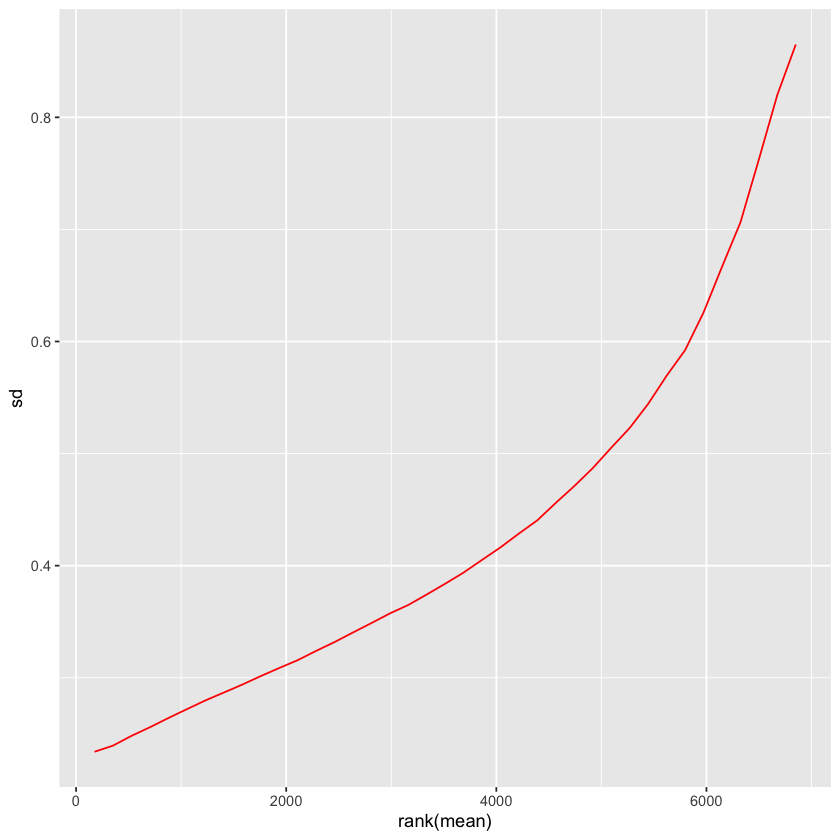

In [122]:
# this gives log2(n + 1)
ntd <- normTransform(dds)
library("vsn")
meanSdPlot(assay(ntd))

In [123]:
colData(dds)

DataFrame with 4052 rows and 4 columns
                        batch condition  cluster sizeFactor
                     <factor>  <factor> <factor>  <numeric>
AGCTTGACAATGGACG-1_1      K1B         2        2   1.155350
CTAGCCTCAATCACAC-1_1      K1B         2        2   0.777052
CGAGCACAGGTTCCTA-1_1      K1B         2        2   3.066494
ATCATGGGTGGTCTCG-1_1      K1B         2        2   1.251420
TCTTTCCGTCTAGTCA-1_1      K1B         2        2   1.362156
...                       ...       ...      ...        ...
ACATACGGTCCAGTTA-1_8      K8B         1        1   1.131128
GCAGCCACATCACGTA-1_8      K8B         1        1   1.051387
GAACCTATCAGATAAG-1_8      K8B         1        1   0.867889
AGTTGGTGTGCAGTAG-1_8      K8B         1        1   2.241964
ACTTGTTGTCTTTCAT-1_8      K8B         1        1   1.136211

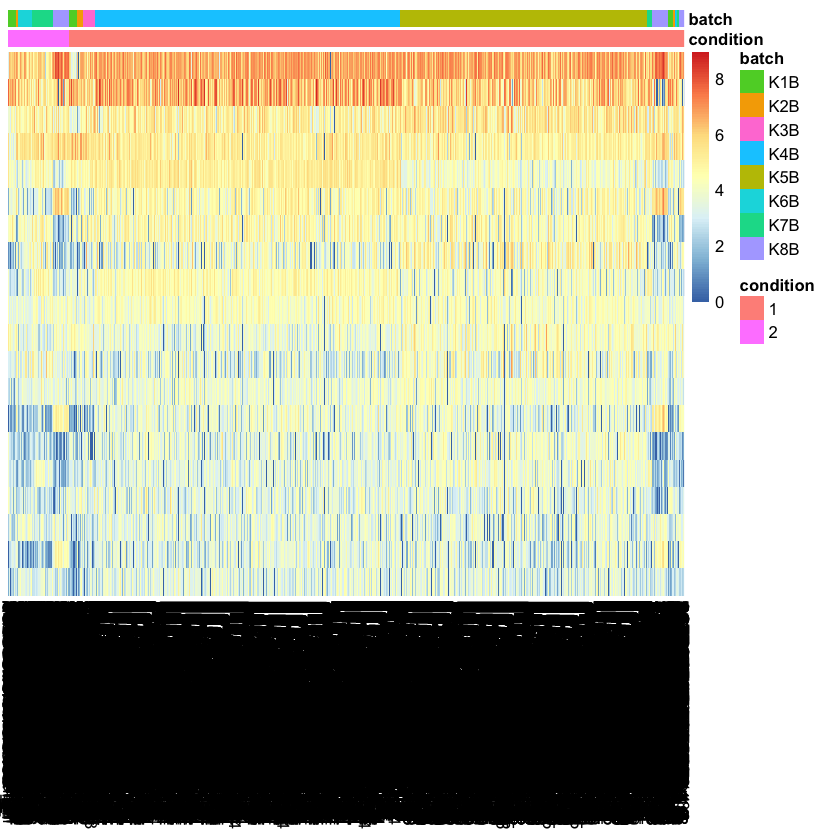

In [124]:
library("pheatmap")
select <- order(rowMeans(counts(dds,normalized=TRUE)),
                decreasing=TRUE)[1:20]
df <- as.data.frame(colData(dds)[,c("condition","batch")])
pheatmap(assay(ntd)[select,], cluster_rows=FALSE, show_rownames=FALSE,
         cluster_cols=FALSE, annotation_col=df)

In [ ]:
vsd <- vst(dds, blind=FALSE, nsub=48)
rld <- rlog(dds, blind=FALSE)
head(assay(vsd), 3)

-- note: fitType='parametric', but the dispersion trend was not well captured by the
   function: y = a/x + b, and a local regression fit was automatically substituted.
   specify fitType='local' or 'mean' to avoid this message next time.

rlog() may take a long time with 50 or more samples,
vst() is a much faster transformation



In [ ]:
sum( rowMeans( counts(dds, normalized=TRUE)) > 5 )

In [126]:
nrow(dds)

[1] 6604